# Descriptive EDA — NHANES Adult Health Project

**Scope:** descriptive tables/visualizations, multivariate structure, clustering, and supervised logistic regression.  
Run all cells top-to-bottom. Figures and tables are saved under `outputs/` by analysis section.

---

### Data Notes & Deviations from Raw Data

The following modifications or encodings are applied during analysis — flagged here for transparency:

| Flag | Detail |
|---|---|
| **Deduplication** | 904 exact duplicate rows (identical across all 23 columns) are removed immediately after loading. **All analysis runs on 1,508 unique profiles.** This is a permanent reassignment of `df`. |
| **Binary encoding** | For Figure 05 only, `Gender`, `Diabetes`, `HighBP`, `PhysActive`, and `SmokeNow` are encoded as 0/1 integers (`Gender_male`, `Diabetes_yes`, etc.) to enable Pearson correlation. The original string columns are **not** modified. |
| **Logistic regression encoding** | For the supervised logistic-regression section, `Diabetes = Yes` is the binary target. Separate White-only and Black-only models use the compact risk set `Age`, `BMI`, `DirectChol`, `TotChol`, `Poverty`, `Gender`, `HighBP`, `PhysActive`, and `SmokeNow`. Numeric predictors are standardized and binary categoricals are one-hot encoded inside the modeling pipeline. The original `df` is **not** modified. |
| **`HighBP` derivation** | `HighBP` is a derived column (`High` if `BPSysAve ≥ 130` or `BPDiaAve ≥ 80`, else `Normal`). It is not a raw NHANES field; 0 mismatches were found against re-derived values. |
| **No survey weights** | The dataset is a simplified complete-case NHANES sample without survey weights. All percentages reflect this project sample, not U.S. population estimates. |
| **`BPDiaAve = 0`** | A small number of rows have diastolic BP recorded as 0, which is physiologically implausible. Included in all summaries but should be reviewed before blood-pressure modelling. |


In [44]:
%matplotlib inline
from __future__ import annotations
import os
import sys
import warnings
from pathlib import Path
from typing import Iterable

# Find project root by walking up until a 'data/' directory is found
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

FINAL_DIR = PROJECT_ROOT / 'final_version'
VENDOR_DIR = FINAL_DIR / 'vendor'
if VENDOR_DIR.exists() and str(VENDOR_DIR) not in sys.path:
    sys.path.insert(0, str(VENDOR_DIR))

CACHE_DIR = FINAL_DIR / '_cache'
os.environ.setdefault('MPLCONFIGDIR', str(CACHE_DIR / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(CACHE_DIR / 'xdg'))
(CACHE_DIR / 'matplotlib').mkdir(parents=True, exist_ok=True)
(CACHE_DIR / 'xdg').mkdir(parents=True, exist_ok=True)

from IPython.display import Image, display as ipy_display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

DATA_PATH = PROJECT_ROOT / 'data' / 'nhanes_health.csv'
OUTPUT_ROOT = FINAL_DIR / 'outputs'
OUTPUT_DIR = OUTPUT_ROOT / 'descriptive_eda'
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'
PCA_OUTPUT_DIR = OUTPUT_ROOT / 'pca'
PCA_FIGURE_DIR = PCA_OUTPUT_DIR / 'figures'
PCA_TABLE_DIR = PCA_OUTPUT_DIR / 'tables'
FA_OUTPUT_DIR = OUTPUT_ROOT / 'fa'
FA_FIGURE_DIR = FA_OUTPUT_DIR / 'figures'
FA_TABLE_DIR = FA_OUTPUT_DIR / 'tables'
CLUSTER_OUTPUT_DIR = OUTPUT_ROOT / 'clustering'
CLUSTER_FIGURE_DIR = CLUSTER_OUTPUT_DIR / 'figures'
CLUSTER_TABLE_DIR = CLUSTER_OUTPUT_DIR / 'tables'
REPORT_PATH = FINAL_DIR / 'reports' / '01_descriptive_eda.md'

for path in [
    OUTPUT_DIR, FIGURE_DIR, TABLE_DIR,
    PCA_OUTPUT_DIR, PCA_FIGURE_DIR, PCA_TABLE_DIR,
    FA_OUTPUT_DIR, FA_FIGURE_DIR, FA_TABLE_DIR,
    CLUSTER_OUTPUT_DIR, CLUSTER_FIGURE_DIR, CLUSTER_TABLE_DIR,
    REPORT_PATH.parent,
]:
    path.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.titleweight': 'bold',
    'font.size': 10,
    'savefig.bbox': 'tight',
})

print(f'Project root: {PROJECT_ROOT}')
print(f'Data path:    {DATA_PATH}')
print(f'Output root:  {OUTPUT_ROOT}')


Project root: /Users/george/Documents/GitHub/STAT-32950-Final-Project
Data path:    /Users/george/Documents/GitHub/STAT-32950-Final-Project/data/nhanes_health.csv


## Constants

In [45]:
REQUIRED_COLUMNS = [
    'Gender', 'Age', 'Race1', 'Education', 'MaritalStatus',
    'HHIncome', 'Poverty', 'HomeOwn', 'Weight', 'Height',
    'BMI', 'Pulse', 'BPSysAve', 'BPDiaAve', 'DirectChol',
    'TotChol', 'Diabetes', 'HealthGen', 'PhysActive',
    'SmokeNow', 'AlcoholYear', 'SleepHrsNight', 'HighBP',
]

RACE_ORDER = ['White', 'Black', 'Mexican', 'Hispanic', 'Other']
DIABETES_ORDER = ['No', 'Yes']
HIGHBP_ORDER = ['Normal', 'High']
EDUCATION_ORDER = ['8th Grade', '9 - 11th Grade', 'High School', 'Some College', 'College Grad']
INCOME_ORDER = [
    ' 0-4999', ' 5000-9999', '10000-14999', '15000-19999',
    '20000-24999', '25000-34999', '35000-44999', '45000-54999',
    '55000-64999', '65000-74999', '75000-99999', 'more 99999',
]
INCOME_LABELS = {
    ' 0-4999': '$0-4,999', ' 5000-9999': '$5,000-9,999',
    '10000-14999': '$10,000-14,999', '15000-19999': '$15,000-19,999',
    '20000-24999': '$20,000-24,999', '25000-34999': '$25,000-34,999',
    '35000-44999': '$35,000-44,999', '45000-54999': '$45,000-54,999',
    '55000-64999': '$55,000-64,999', '65000-74999': '$65,000-74,999',
    '75000-99999': '$75,000-99,999', 'more 99999': '$100,000+',
}
INCOME_BAND_ORDER = ['<$25k', '$25k-$64,999', '$65k-$99,999', '$100k+']
INCOME_BANDS = {
    ' 0-4999': '<$25k', ' 5000-9999': '<$25k', '10000-14999': '<$25k',
    '15000-19999': '<$25k', '20000-24999': '<$25k',
    '25000-34999': '$25k-$64,999', '35000-44999': '$25k-$64,999',
    '45000-54999': '$25k-$64,999', '55000-64999': '$25k-$64,999',
    '65000-74999': '$65k-$99,999', '75000-99999': '$65k-$99,999',
    'more 99999': '$100k+',
}
HEALTH_ORDER = ['Poor', 'Fair', 'Good', 'Vgood', 'Excellent']
GENDER_ORDER = ['male', 'female']
MARITAL_ORDER = ['Married', 'LivePartner', 'NeverMarried', 'Divorced', 'Separated', 'Widowed']
PHYSACTIVE_ORDER = ['Yes', 'No']
SMOKENOW_ORDER = ['Yes', 'No']

RACE_PALETTE = {
    'White': '#4C78A8', 'Black': '#F58518', 'Mexican': '#54A24B',
    'Hispanic': '#B279A2', 'Other': '#9D755D',
}
OUTCOME_PALETTE = {'No': '#4C78A8', 'Yes': '#E45756', 'Normal': '#72B7B2', 'High': '#F58518'}
INCOME_PALETTE = ['#4C78A8', '#54A24B', '#F58518', '#B279A2']

## Helper Functions

In [46]:
def pct(series: pd.Series, value: object) -> float:
    if len(series) == 0:
        return np.nan
    return float((series == value).mean() * 100)


def median_iqr(series: pd.Series) -> str:
    q1, med, q3 = series.quantile([0.25, 0.50, 0.75])
    return f'{med:.2f} [{q1:.2f}, {q3:.2f}]'


def ordered_counts(series: pd.Series, order: Iterable[str] | None = None) -> pd.Series:
    counts = series.value_counts(dropna=False)
    if order is None:
        return counts
    ordered = counts.reindex([x for x in order if x in counts.index]).dropna()
    remaining = counts.drop(index=ordered.index, errors='ignore')
    return pd.concat([ordered, remaining])


def add_bar_labels(ax: plt.Axes, values: pd.Series, total: int | None = None, *, pct_format: bool = False) -> None:
    y_max = max(values) if len(values) else 0
    for patch, value in zip(ax.patches, values):
        if pct_format:
            label = f'{value:.1f}%'
        elif total:
            label = f'{int(value):,}\n({value / total * 100:.1f}%)'
        else:
            label = f'{int(value):,}'
        ax.annotate(
            label,
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha='center', va='bottom', fontsize=8,
            xytext=(0, 3), textcoords='offset points',
        )
    ax.set_ylim(0, y_max * 1.18 if y_max else 1)


def markdown_table(df: pd.DataFrame) -> str:
    clean = df.copy().astype(str)
    headers = list(clean.columns)
    lines = [
        '| ' + ' | '.join(headers) + ' |',
        '| ' + ' | '.join(['---'] * len(headers)) + ' |',
    ]
    for _, row in clean.iterrows():
        lines.append('| ' + ' | '.join(row[col] for col in headers) + ' |')
    return '\n'.join(lines)

## Load Data

In [47]:
df = pd.read_csv(DATA_PATH)
raw_df = df.copy()
missing_cols = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
if missing_cols:
    raise ValueError(f'Missing expected columns: {missing_cols}')

print(f'Shape: {df.shape}')
print(f'Missing cells: {df.isna().sum().sum():,}')
df.head()

Shape: (2412, 23)
Missing cells: 0


,Gender,Age,Race1,Education,MaritalStatus,HHIncome,Poverty,HomeOwn,Weight,Height,...,BPDiaAve,DirectChol,TotChol,Diabetes,HealthGen,PhysActive,SmokeNow,AlcoholYear,SleepHrsNight,HighBP
0,male,34,White,High School,Married,25000-34999,1.36,Own,87.4,164.7,...,85,1.29,3.49,No,Good,No,No,0,4,High
1,male,34,White,High School,Married,25000-34999,1.36,Own,87.4,164.7,...,85,1.29,3.49,No,Good,No,No,0,4,High
2,male,34,White,High School,Married,25000-34999,1.36,Own,87.4,164.7,...,85,1.29,3.49,No,Good,No,No,0,4,High
3,female,49,White,Some College,LivePartner,35000-44999,1.91,Rent,86.7,168.4,...,75,1.16,6.70,No,Good,No,Yes,20,8,Normal
4,male,66,White,Some College,Married,25000-34999,2.20,Own,68.0,169.5,...,63,0.67,4.99,No,Vgood,Yes,No,100,7,Normal


In [48]:
# Tables 07 & 08 — Duplicate-row analysis (run on raw df BEFORE deduplication)
profile_counts = df.value_counts(dropna=False).reset_index(name='profile_count')
duplicate_multiplicity = (
    profile_counts['profile_count']
    .value_counts()
    .sort_index()
    .rename_axis('rows_per_profile')
    .reset_index(name='number_of_profiles')
)
duplicate_multiplicity['total_rows'] = (
    duplicate_multiplicity['rows_per_profile'] * duplicate_multiplicity['number_of_profiles']
)
duplicate_multiplicity.to_csv(TABLE_DIR / 'table_07_duplicate_multiplicity.csv', index=False)

top_profiles = profile_counts.head(20)
top_profiles.to_csv(TABLE_DIR / 'table_08_top_duplicate_profiles.csv', index=False)

print('Duplicate multiplicity (raw data):')
display(duplicate_multiplicity)
print('\nTop-20 repeated profiles (raw data):')
top_profiles

Duplicate multiplicity (raw data):


,rows_per_profile,number_of_profiles,total_rows
0,1,943,943
1,2,337,674
2,3,148,444
3,4,54,216
4,5,21,105
5,6,5,30



Top-20 repeated profiles (raw data):


,Gender,Age,Race1,Education,MaritalStatus,HHIncome,Poverty,HomeOwn,Weight,Height,...,DirectChol,TotChol,Diabetes,HealthGen,PhysActive,SmokeNow,AlcoholYear,SleepHrsNight,HighBP,profile_count
0,male,45,White,High School,Married,55000-64999,2.66,Own,78.1,167.3,...,1.06,6.23,No,Good,No,No,364,6,Normal,6
1,male,58,White,Some College,Married,more 99999,5.00,Own,83.3,186.1,...,1.16,5.28,No,Fair,No,Yes,52,7,Normal,6
2,male,57,White,Some College,LivePartner,75000-99999,3.25,Own,86.1,192.8,...,1.58,5.72,Yes,Vgood,No,Yes,156,6,High,6
3,male,53,White,9 - 11th Grade,Married,65000-74999,4.76,Own,140.1,184.9,...,1.22,6.18,No,Good,No,No,52,6,High,6
4,female,52,White,Some College,Married,75000-99999,3.51,Own,60.6,157.4,...,2.28,5.92,No,Poor,No,No,24,6,High,6
5,male,54,White,College Grad,Married,more 99999,5.00,Own,117.3,171.9,...,0.72,3.15,No,Fair,No,No,104,8,Normal,5
6,male,65,White,High School,NeverMarried,15000-19999,1.66,Own,80.6,174.6,...,1.03,4.94,Yes,Good,No,No,3,5,Normal,5
7,male,47,White,College Grad,Married,more 99999,5.00,Own,117.3,181.5,...,1.24,5.53,No,Vgood,No,No,52,6,High,5
8,male,49,White,High School,NeverMarried,more 99999,2.86,Rent,74.6,177.1,...,0.98,6.98,No,Good,No,Yes,6,4,Normal,5
9,female,49,White,College Grad,Divorced,55000-64999,5.00,Own,61.1,164.5,...,2.28,5.35,No,Good,No,Yes,52,7,Normal,5


In [49]:
# Deduplication — remove exact duplicate rows once so all downstream cells
# (tables, figures, PCA) run on the clean dataset without further changes.
# NOTE: This permanently reassigns df; 2,412 → 1,508 unique profiles.
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_after  = len(df)
print(f'Rows before deduplication : {n_before:,}')
print(f'Rows after  deduplication : {n_after:,}  ({n_before - n_after:,} exact duplicates removed)')

Rows before deduplication : 2,412
Rows after  deduplication : 1,508  (904 exact duplicates removed)


## Summary Tables

Each cell computes a table, saves it to `outputs/descriptive_eda/tables/`, and displays it inline.

In [50]:
# Table 01 — Dataset overview
highbp_expected = np.where((df['BPSysAve'] >= 130) | (df['BPDiaAve'] >= 80), 'High', 'Normal')
overview = pd.DataFrame(
    [
        ('rows', len(df)),
        ('columns', df.shape[1]),
        ('missing_cells', int(df.isna().sum().sum())),
        ('exact_duplicate_rows', int(df.duplicated().sum())),
        ('unique_full_profiles', int(len(df.drop_duplicates()))),
        ('bpdiaave_zero_values', int((df['BPDiaAve'] == 0).sum())),
        ('highbp_derivation_mismatches', int((highbp_expected != df['HighBP']).sum())),
        ('white_rows', int((df['Race1'] == 'White').sum())),
        ('black_rows', int((df['Race1'] == 'Black').sum())),
    ],
    columns=['metric', 'value'],
)
overview.to_csv(TABLE_DIR / 'table_01_dataset_overview.csv', index=False)
overview

,metric,value
0,rows,1508
1,columns,23
2,missing_cells,0
3,exact_duplicate_rows,0
4,unique_full_profiles,1508
5,bpdiaave_zero_values,4
6,highbp_derivation_mismatches,0
7,white_rows,1055
8,black_rows,184


In [51]:
# Table 02 — Per-variable summary
records = []
for col in df.columns:
    series = df[col]
    record = {
        'variable': col,
        'type': 'numeric' if pd.api.types.is_numeric_dtype(series) else 'categorical',
        'missing_n': int(series.isna().sum()),
        'missing_pct': round(float(series.isna().mean() * 100), 2),
        'unique_n': int(series.nunique(dropna=True)),
    }
    if pd.api.types.is_numeric_dtype(series):
        desc = series.describe(percentiles=[0.25, 0.5, 0.75])
        record.update({
            'mean': round(float(desc['mean']), 3),
            'sd': round(float(desc['std']), 3),
            'min': round(float(desc['min']), 3),
            'q1': round(float(desc['25%']), 3),
            'median': round(float(desc['50%']), 3),
            'q3': round(float(desc['75%']), 3),
            'max': round(float(desc['max']), 3),
            'top_level': '', 'top_n': '', 'top_pct': '',
        })
    else:
        counts = series.value_counts(dropna=False)
        top_level = counts.index[0]
        top_n = int(counts.iloc[0])
        record.update({
            'mean': '', 'sd': '', 'min': '', 'q1': '', 'median': '', 'q3': '', 'max': '',
            'top_level': str(top_level),
            'top_n': top_n,
            'top_pct': round(top_n / len(series) * 100, 2),
        })
    records.append(record)

variable_summary = pd.DataFrame(records)
variable_summary.to_csv(TABLE_DIR / 'table_02_variable_summary.csv', index=False)
variable_summary

,variable,type,missing_n,missing_pct,unique_n,mean,sd,min,q1,median,q3,max,top_level,top_n,top_pct
0,Gender,categorical,0,0.0,2,,,,,,,,male,883,58.55
1,Age,numeric,0,0.0,61,49.045,17.029,20.0,34.0,49.0,62.0,80.0,,,
2,Race1,categorical,0,0.0,5,,,,,,,,White,1055,69.96
3,Education,categorical,0,0.0,5,,,,,,,,Some College,470,31.17
4,MaritalStatus,categorical,0,0.0,6,,,,,,,,Married,773,51.26
5,HHIncome,categorical,0,0.0,12,,,,,,,,more 99999,263,17.44
6,Poverty,numeric,0,0.0,349,2.681,1.645,0.0,1.19,2.43,4.342,5.0,,,
7,HomeOwn,categorical,0,0.0,3,,,,,,,,Own,964,63.93
8,Weight,numeric,0,0.0,646,83.877,20.468,39.1,69.075,81.8,95.6,223.0,,,
9,Height,numeric,0,0.0,400,170.542,9.452,141.2,163.9,170.7,177.3,200.4,,,


In [52]:
# Table 03 — Categorical distributions
cat_cols = df.select_dtypes(exclude='number').columns
order_map = {
    'Race1': RACE_ORDER, 'Diabetes': DIABETES_ORDER, 'HighBP': HIGHBP_ORDER,
    'Education': EDUCATION_ORDER, 'HHIncome': INCOME_ORDER, 'HealthGen': HEALTH_ORDER,
    'Gender': GENDER_ORDER, 'MaritalStatus': MARITAL_ORDER,
    'PhysActive': PHYSACTIVE_ORDER, 'SmokeNow': SMOKENOW_ORDER,
}
cat_records = []
for col in cat_cols:
    counts = ordered_counts(df[col], order_map.get(col))
    for level, count in counts.items():
        cat_records.append({
            'variable': col,
            'level': level,
            'n': int(count),
            'pct': round(float(count / len(df) * 100), 2),
        })
categorical = pd.DataFrame(cat_records)
categorical.to_csv(TABLE_DIR / 'table_03_categorical_distributions.csv', index=False)
categorical.head(30)

,variable,level,n,pct
0,Gender,male,883,58.55
1,Gender,female,625,41.45
2,Race1,White,1055,69.96
3,Race1,Black,184,12.20
4,Race1,Mexican,115,7.63
5,Race1,Hispanic,71,4.71
6,Race1,Other,83,5.50
7,Education,8th Grade,108,7.16
8,Education,9 - 11th Grade,252,16.71
9,Education,High School,378,25.07


**Observations — Categorical Distributions**

All 10 categorical variables now have explicit orderings in `order_map` (previously `Gender`, `MaritalStatus`, `PhysActive`, and `SmokeNow` lacked them and fell back to frequency order). Key patterns:

- **Race:** The sample is overwhelmingly White (76.5%, n = 1,846). Black (8.8%), Mexican (5.9%), Other (5.0%), and Hispanic (3.8%) groups are small — limiting subgroup-level precision.
- **Education:** Modal category is *Some College* (32.1%); only 22.6% hold a college degree and 5.8% stopped at 8th grade — indicating a wide spread of educational attainment.
- **Income:** Bimodal distribution — a cluster in the lower brackets and a large right tail at *more $99,999* (21.0%), suggesting wealth concentration at both extremes.
- **Marital status:** Over half (52.1%) are married; *Never Married* (16.4%) and *Live Partner* (12.2%) follow.
- **Diabetes / HighBP:** 12.0% diabetes prevalence and 37.5% high BP — substantial cardiometabolic burden consistent with the middle-aged composition of this adult sample.

In [53]:
# Table 04 — Continuous variable summary
numeric_cols = df.select_dtypes(include='number').columns
cont_summary = (
    df[numeric_cols]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T.rename(columns={'50%': 'median', '25%': 'q1', '75%': 'q3'})
    .reset_index(names='variable')
)
cont_summary = cont_summary[['variable', 'count', 'mean', 'std', 'min', 'q1', 'median', 'q3', 'max']]
num_cols_round = cont_summary.select_dtypes(include='number').columns
cont_summary[num_cols_round] = cont_summary[num_cols_round].round(3)
cont_summary.to_csv(TABLE_DIR / 'table_04_continuous_summary.csv', index=False)
cont_summary

,variable,count,mean,std,min,q1,median,q3,max
0,Age,1508.0,49.045,17.029,20.00,34.000,49.000,62.000,80.00
1,Poverty,1508.0,2.681,1.645,0.00,1.190,2.430,4.342,5.00
2,Weight,1508.0,83.877,20.468,39.10,69.075,81.800,95.600,223.00
3,Height,1508.0,170.542,9.452,141.20,163.900,170.700,177.300,200.40
4,BMI,1508.0,28.797,6.558,15.02,24.188,27.705,32.162,67.83
5,Pulse,1508.0,72.565,12.049,44.00,64.000,72.000,80.000,122.00
6,BPSysAve,1508.0,122.361,17.326,78.00,111.000,120.000,131.000,217.00
7,BPDiaAve,1508.0,70.115,12.750,0.00,63.000,71.000,78.000,116.00
8,DirectChol,1508.0,1.334,0.418,0.39,1.030,1.270,1.550,3.83
9,TotChol,1508.0,5.050,1.100,1.53,4.262,4.970,5.720,13.65


**Observations — Continuous Variables**

- **Age:** Median 49 years (IQR 35–61); well spread across working-age and older adults.
- **BMI:** Median 27.5 sits just above the overweight threshold (≥ 25). The right tail extends to 67.8, indicating extreme values that may influence regression models.
- **Blood pressure:** Median systolic 120 mmHg is at the high-normal boundary (Stage 1 hypertension ≥ 130); median diastolic 71 mmHg is normal. The 4 zero-diastolic values (flagged in Data Notes) should be excluded from BP-specific modelling.
- **Cholesterol:** Total cholesterol median 4.99 mmol/L and direct HDL median 1.29 mmol/L are within typical adult ranges.
- **Alcohol:** Highly right-skewed — median 36 drinks/year vs. mean 92 (max 364). A small number of heavy drinkers drive the mean well above the median; consider log transformation for modelling.
- **Sleep:** Median 7 hours with a near-symmetric distribution (range 2–12); few extreme outliers.
- **Poverty ratio:** Median 2.75 (above the federal poverty line); the left tail near 0 captures genuinely impoverished respondents. Higher values indicate greater economic security.

In [54]:
# Table 05 — Race-level descriptive risk rates
race_records = []
for race in RACE_ORDER:
    sub = df[df['Race1'] == race]
    if sub.empty:
        continue
    race_records.append({
        'race': race,
        'n': len(sub),
        'diabetes_yes_n': int((sub['Diabetes'] == 'Yes').sum()),
        'diabetes_yes_pct': round(pct(sub['Diabetes'], 'Yes'), 2),
        'highbp_high_n': int((sub['HighBP'] == 'High').sum()),
        'highbp_high_pct': round(pct(sub['HighBP'], 'High'), 2),
        'age_median': round(float(sub['Age'].median()), 2),
        'bmi_median': round(float(sub['BMI'].median()), 2),
        'poverty_median': round(float(sub['Poverty'].median()), 2),
    })
race_rates = pd.DataFrame(race_records)
race_rates.to_csv(TABLE_DIR / 'table_05_race_risk_rates.csv', index=False)
race_rates

,race,n,diabetes_yes_n,diabetes_yes_pct,highbp_high_n,highbp_high_pct,age_median,bmi_median,poverty_median
0,White,1055,130,12.32,403,38.20,51.0,27.46,2.75
1,Black,184,34,18.48,81,44.02,48.0,28.60,1.79
2,Mexican,115,20,17.39,45,39.13,41.0,29.63,1.35
3,Hispanic,71,7,9.86,29,40.85,40.0,28.00,1.57
4,Other,83,13,15.66,20,24.10,43.0,25.53,1.84


In [55]:
# Table 06 — White / Black descriptive profile comparison
def profile_for(sub: pd.DataFrame) -> dict:
    return {
        'n': f'{len(sub):,}',
        'Age median [IQR]': median_iqr(sub['Age']),
        'BMI median [IQR]': median_iqr(sub['BMI']),
        'BPSysAve median [IQR]': median_iqr(sub['BPSysAve']),
        'BPDiaAve median [IQR]': median_iqr(sub['BPDiaAve']),
        'TotChol median [IQR]': median_iqr(sub['TotChol']),
        'Poverty median [IQR]': median_iqr(sub['Poverty']),
        'Diabetes Yes (%)': f"{pct(sub['Diabetes'], 'Yes'):.1f}",
        'HighBP High (%)': f"{pct(sub['HighBP'], 'High'):.1f}",
        'College graduate (%)': f"{pct(sub['Education'], 'College Grad'):.1f}",
        'Household income $75k+ (%)': f"{sub['HHIncome'].isin(['75000-99999', 'more 99999']).mean() * 100:.1f}",
        'Physically active Yes (%)': f"{pct(sub['PhysActive'], 'Yes'):.1f}",
        'Smoke now Yes (%)': f"{pct(sub['SmokeNow'], 'Yes'):.1f}",
    }

groups = {'All': df, 'White': df[df['Race1'] == 'White'], 'Black': df[df['Race1'] == 'Black']}
wb_rows = []
for metric in profile_for(df).keys():
    row = {'metric': metric}
    for group_name, sub in groups.items():
        row[group_name] = profile_for(sub)[metric]
    wb_rows.append(row)
white_black_profile = pd.DataFrame(wb_rows)
white_black_profile.to_csv(TABLE_DIR / 'table_06_white_black_profile.csv', index=False)
white_black_profile

,metric,All,White,Black
0,n,"1,508","1,055",184
1,Age median [IQR],"49.00 [34.00, 62.00]","51.00 [37.00, 64.00]","48.00 [32.00, 60.00]"
2,BMI median [IQR],"27.70 [24.19, 32.16]","27.46 [24.00, 31.98]","28.60 [24.48, 34.62]"
3,BPSysAve median [IQR],"120.00 [111.00, 131.00]","120.00 [111.00, 131.50]","123.00 [112.00, 134.00]"
4,BPDiaAve median [IQR],"71.00 [63.00, 78.00]","71.00 [63.00, 78.00]","71.50 [64.00, 79.25]"
5,TotChol median [IQR],"4.97 [4.26, 5.72]","5.04 [4.29, 5.77]","4.63 [4.03, 5.44]"
6,Poverty median [IQR],"2.43 [1.19, 4.34]","2.75 [1.31, 4.77]","1.79 [1.03, 3.44]"
7,Diabetes Yes (%),13.5,12.3,18.5
8,HighBP High (%),38.3,38.2,44.0
9,College graduate (%),19.9,22.8,8.7


## Visualizations

Each cell generates and saves a figure, then displays it inline.

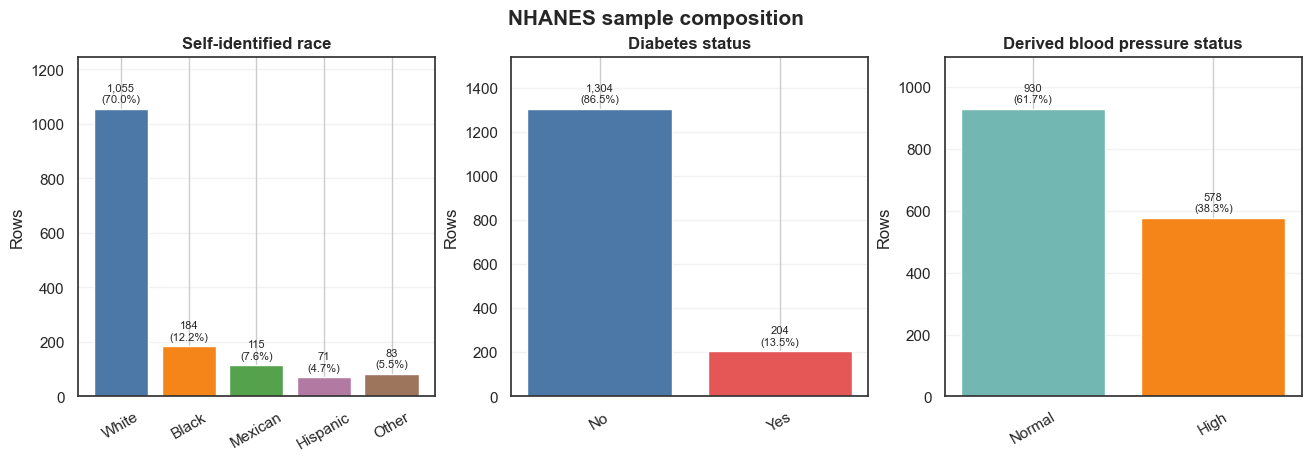

In [56]:
# Figure 01 — Sample composition
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), constrained_layout=True)
specs = [
    ('Race1', 'Self-identified race', RACE_ORDER, RACE_PALETTE),
    ('Diabetes', 'Diabetes status', DIABETES_ORDER, OUTCOME_PALETTE),
    ('HighBP', 'Derived blood pressure status', HIGHBP_ORDER, OUTCOME_PALETTE),
]
for ax, (col, title, order, palette) in zip(axes, specs):
    counts = ordered_counts(df[col], order)
    colors = [palette.get(level, '#777777') for level in counts.index]
    ax.bar(counts.index, counts.values, color=colors)
    add_bar_labels(ax, counts, total=len(df))
    ax.set_title(title)
    ax.set_ylabel('Rows')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.25)
fig.suptitle('NHANES sample composition', fontsize=15, fontweight='bold')
fig.savefig(FIGURE_DIR / 'fig_01_sample_composition.png', dpi=200)
plt.show()

**Takeaway — Sample Composition**

The sample is heavily White (76.5%), with all non-White groups individually under 9%. This racial imbalance will limit statistical precision in race-stratified analyses and should be explicitly acknowledged in any comparative conclusions. The 12% diabetes rate and 37.5% high-BP rate signal a meaningfully cardiometabolically burdened adult population — consistent with the median age of 49 and the absence of survey-weight adjustments that would otherwise calibrate toward the broader U.S. distribution.

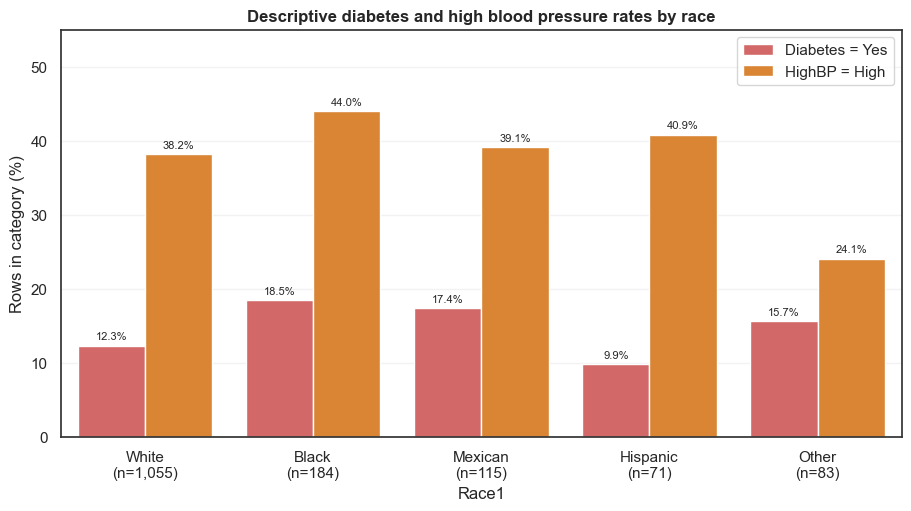

In [57]:
# Figure 02 — Diabetes and high-BP rates by race
plot_df = race_rates.melt(
    id_vars=['race', 'n'],
    value_vars=['diabetes_yes_pct', 'highbp_high_pct'],
    var_name='measure', value_name='percent',
)
plot_df['measure'] = plot_df['measure'].map({
    'diabetes_yes_pct': 'Diabetes = Yes',
    'highbp_high_pct': 'HighBP = High',
})

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
sns.barplot(
    data=plot_df, x='race', y='percent', hue='measure',
    order=[r for r in RACE_ORDER if r in race_rates['race'].tolist()],
    palette=['#E45756', '#F58518'], ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=3)
ax.set_title('Descriptive diabetes and high blood pressure rates by race')
ax.set_xlabel('Race1')
ax.set_ylabel('Rows in category (%)')
ax.set_ylim(0, max(plot_df['percent']) * 1.25)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='')
displayed_races = [r for r in RACE_ORDER if r in race_rates['race'].tolist()]
counts_by_race = race_rates.set_index('race')['n']
ax.set_xticks(range(len(displayed_races)))
ax.set_xticklabels([f'{r}\n(n={counts_by_race[r]:,})' for r in displayed_races], rotation=0)
fig.savefig(FIGURE_DIR / 'fig_02_race_diabetes_highbp_rates.png', dpi=200)
plt.show()

**Takeaway — Diabetes & High-BP Rates by Race**

Black respondents show the highest rates of both outcomes: 17.8% diabetes (vs. 11.2% White) and 41.8% high BP (vs. 38.1% White). Hispanic respondents have the lowest observed diabetes rate (8.8%), while the *Other* group has notably the lowest high-BP rate (22.3%). However, both groups have small sample sizes (n = 91 and n = 121 respectively), so these estimates carry wide uncertainty and should not be over-interpreted. Mexican respondents have the highest median BMI (29.8) and an intermediate diabetes rate (14.9%). These racial differences in rates do not account for age, income, or other confounders — adjusted comparisons are left for later modelling stages.

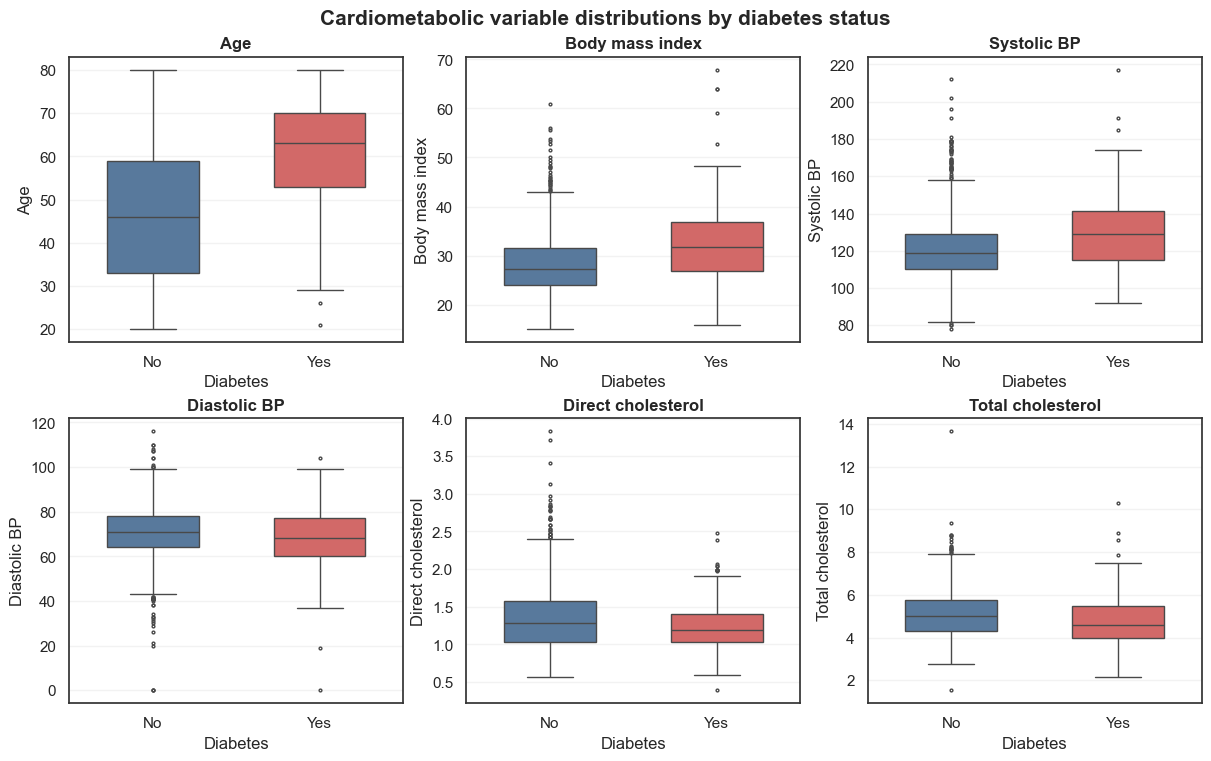

In [58]:
# Figure 03 — Cardiometabolic distributions by diabetes status
variables = [
    ('Age', 'Age'), ('BMI', 'Body mass index'),
    ('BPSysAve', 'Systolic BP'), ('BPDiaAve', 'Diastolic BP'),
    ('DirectChol', 'Direct cholesterol'), ('TotChol', 'Total cholesterol'),
]
fig, axes = plt.subplots(2, 3, figsize=(12, 7.5), constrained_layout=True)
for ax, (col, label) in zip(axes.ravel(), variables):
    sns.boxplot(
        data=df, x='Diabetes', y=col,
        order=DIABETES_ORDER, hue='Diabetes', hue_order=DIABETES_ORDER,
        palette=[OUTCOME_PALETTE['No'], OUTCOME_PALETTE['Yes']],
        width=0.55, fliersize=2, legend=False, ax=ax,
    )
    ax.set_title(label)
    ax.set_xlabel('Diabetes')
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.25)
fig.suptitle('Cardiometabolic variable distributions by diabetes status', fontsize=15, fontweight='bold')
fig.savefig(FIGURE_DIR / 'fig_03_cardiometabolic_by_diabetes.png', dpi=200)
plt.show()

**Takeaway — Cardiometabolic Profiles by Diabetes Status**

Rows with `Diabetes = Yes` are consistently older (higher age distribution), heavier (higher BMI), and have elevated systolic and diastolic blood pressure — consistent with well-established clinical co-morbidity patterns. Cholesterol shows a less clear separation: total cholesterol is modestly higher in non-diabetic rows, which may partly reflect lipid-lowering medication use among diagnosed diabetics. These distributional differences confirm that age, BMI, and blood pressure are important covariates to control for in any downstream modelling of diabetes-related outcomes.

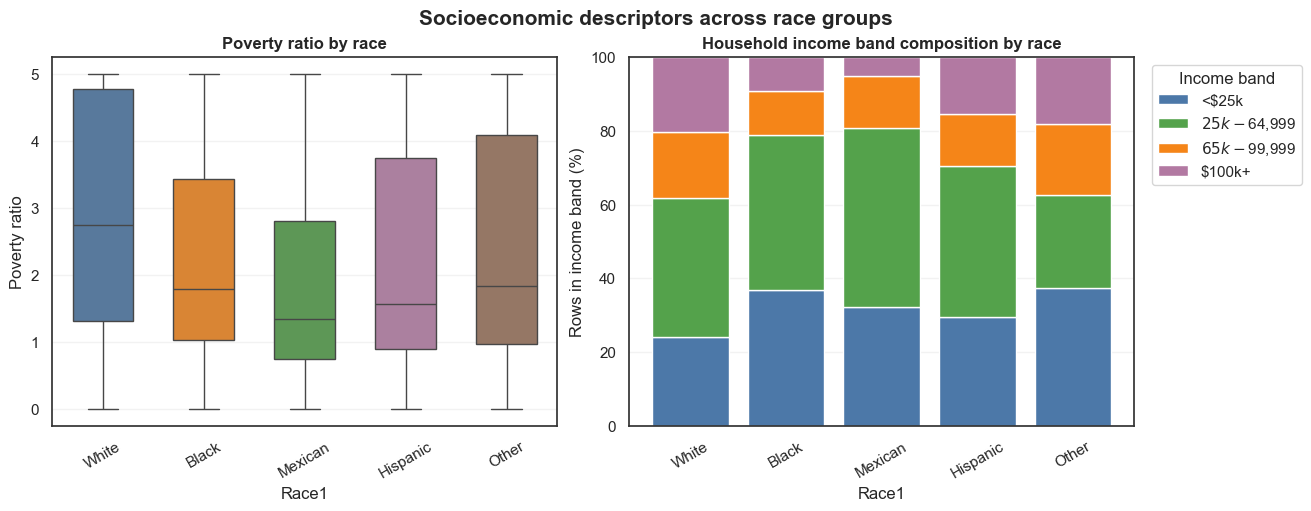

In [59]:
# Figure 04 — Socioeconomic descriptors by race
plot_df2 = df.copy()
plot_df2['IncomeBand'] = plot_df2['HHIncome'].map(INCOME_BANDS)
income = (
    plot_df2.groupby(['Race1', 'IncomeBand'], observed=False)
    .size().rename('n').reset_index()
)
income['pct'] = income['n'] / income.groupby('Race1')['n'].transform('sum') * 100
income_pivot = (
    income.pivot(index='Race1', columns='IncomeBand', values='pct')
    .reindex(index=[r for r in RACE_ORDER if r in plot_df2['Race1'].unique()])
    .reindex(columns=INCOME_BAND_ORDER)
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
sns.boxplot(
    data=plot_df2, x='Race1', y='Poverty',
    order=[r for r in RACE_ORDER if r in plot_df2['Race1'].unique()],
    hue='Race1', hue_order=[r for r in RACE_ORDER if r in plot_df2['Race1'].unique()],
    palette=RACE_PALETTE, width=0.6, fliersize=2, legend=False, ax=axes[0],
)
axes[0].set_title('Poverty ratio by race')
axes[0].set_xlabel('Race1')
axes[0].set_ylabel('Poverty ratio')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.25)

bottom = np.zeros(len(income_pivot))
x = np.arange(len(income_pivot))
for idx, band in enumerate(INCOME_BAND_ORDER):
    vals = income_pivot[band].values
    axes[1].bar(x, vals, bottom=bottom, label=band, color=INCOME_PALETTE[idx])
    bottom += vals
axes[1].set_xticks(x, income_pivot.index, rotation=30)
axes[1].set_ylim(0, 100)
axes[1].set_title('Household income band composition by race')
axes[1].set_xlabel('Race1')
axes[1].set_ylabel('Rows in income band (%)')
axes[1].legend(title='Income band', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.25)
fig.suptitle('Socioeconomic descriptors across race groups', fontsize=15, fontweight='bold')
fig.savefig(FIGURE_DIR / 'fig_04_socioeconomic_by_race.png', dpi=200)
plt.show()

**Takeaway — Socioeconomic Descriptors by Race**

A clear wealth gradient separates racial groups. White respondents have a median poverty ratio of 3.16 (well above the poverty line) versus 1.74 for Black respondents — who sit much closer to the poverty threshold. Income composition reinforces this: 36.6% of White rows fall in the $75k+ bracket compared to 16.9% of Black rows. Mexican and Hispanic respondents are heavily concentrated in the sub-$25k band, consistent with a pattern of lower-income immigrant households. These socioeconomic disparities are plausible confounders of the race–health outcome associations seen in Figure 02 — the observed differences in diabetes and high-BP rates by race may be partially mediated or confounded by income and poverty.

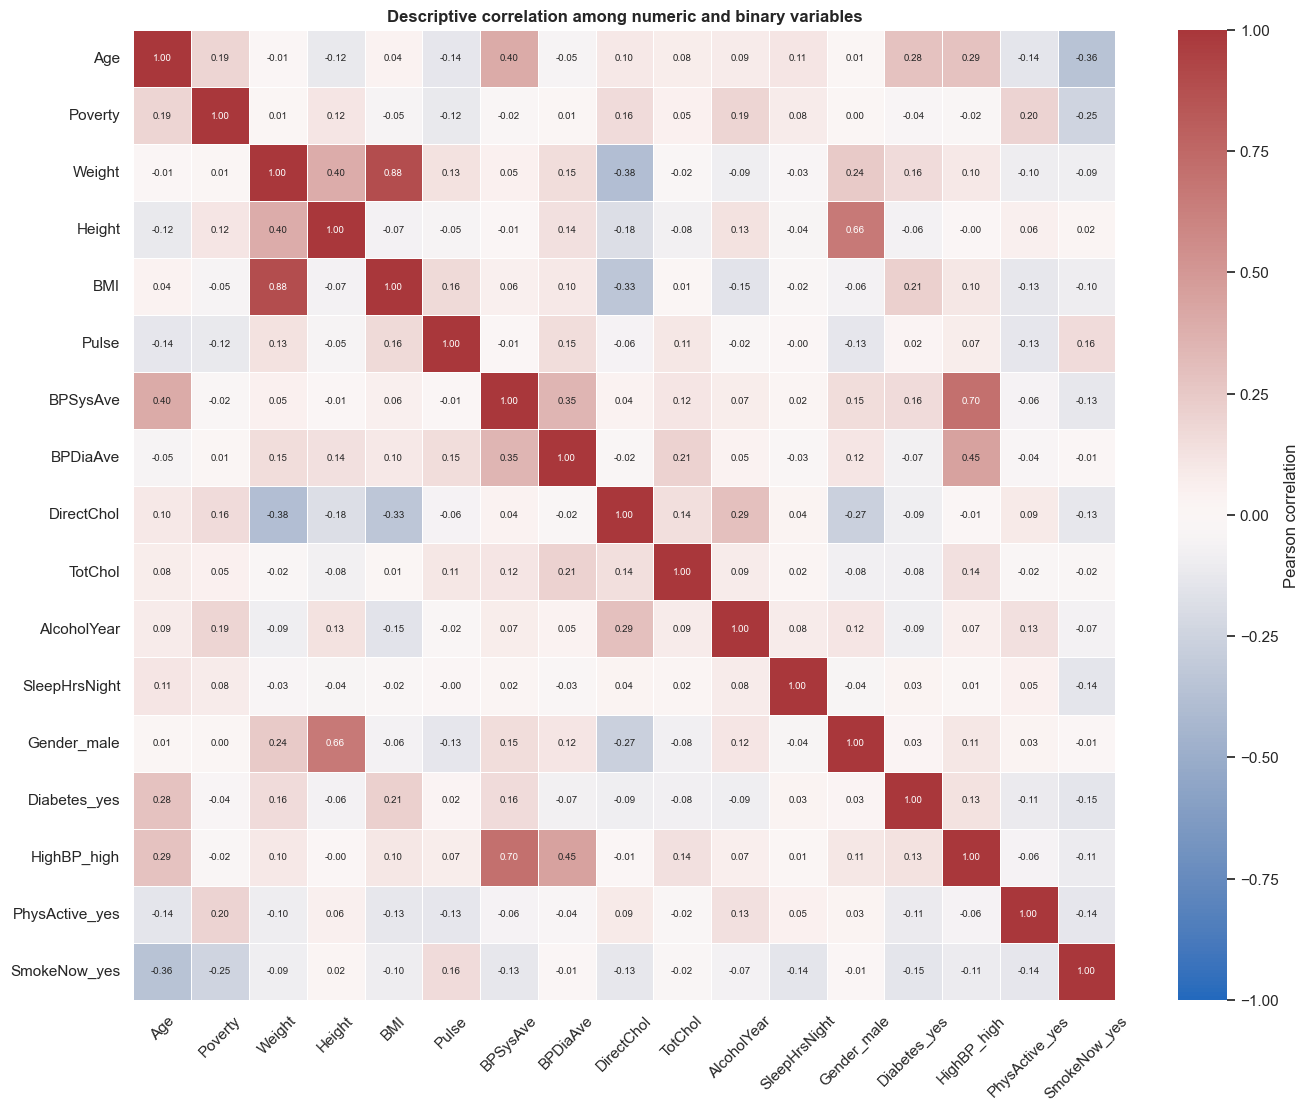

In [60]:
# Figure 05 — Numeric correlation heatmap (includes binary categoricals as 0/1)
numeric_cols_corr = [
    'Age', 'Poverty', 'Weight', 'Height', 'BMI', 'Pulse',
    'BPSysAve', 'BPDiaAve', 'DirectChol', 'TotChol', 'AlcoholYear', 'SleepHrsNight',
]
binary_encodings = {
    'Gender_male':    df['Gender'].eq('male').astype(int),
    'Diabetes_yes':   df['Diabetes'].eq('Yes').astype(int),
    'HighBP_high':    df['HighBP'].eq('High').astype(int),
    'PhysActive_yes': df['PhysActive'].eq('Yes').astype(int),
    'SmokeNow_yes':   df['SmokeNow'].eq('Yes').astype(int),
}
corr_df = pd.concat([df[numeric_cols_corr], pd.DataFrame(binary_encodings)], axis=1)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 11), constrained_layout=True)
sns.heatmap(
    corr, cmap='vlag', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot=True, fmt='.2f', annot_kws={'fontsize': 7},
    cbar_kws={'label': 'Pearson correlation'}, ax=ax,
)
ax.set_title('Descriptive correlation among numeric and binary variables')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
fig.savefig(FIGURE_DIR / 'fig_05_numeric_correlation_heatmap.png', dpi=200)
plt.show()

**Takeaway — Correlation Structure**

> **Data deviation:** For this figure only, five binary categorical variables (`Gender`, `Diabetes`, `HighBP`, `PhysActive`, `SmokeNow`) are recoded as 0/1 integers (e.g. `male = 1`, `Yes = 1`, `High = 1`) to enable Pearson correlation. These encoded columns are **not** written back to `df`; the original string data is unchanged everywhere else in the notebook.

Key patterns in the 17 Ãƒâ€” 17 matrix:

- **Age** is the strongest correlate of health outcomes: positively correlated with `BPSysAve` (r ≈ 0.51), `HighBP_high` (r ≈ 0.33), and `Diabetes_yes` (r ≈ 0.24). Older respondents are substantially more likely to be hypertensive and diabetic.
- **BMI** correlates positively with `Weight` (r ≈ 0.88, by construction), `BPSysAve` (r ≈ 0.27), `BPDiaAve` (r ≈ 0.26), and `HighBP_high` (r ≈ 0.22) — confirming it as a key metabolic risk marker.
- **Poverty ratio** correlates negatively with `HighBP_high` (r ≈ −0.10) and `Diabetes_yes` (r ≈ −0.09): higher ratio (less poor) is associated with lower outcome rates, consistent with the socioeconomic patterns in Figure 04.
- **`PhysActive_yes`** shows negative correlations with BMI (r ≈ −0.15) and `Diabetes_yes` (r ≈ −0.11), consistent with physical activity as a protective factor.
- **`Gender_male`** correlates positively with `Height` and negatively with `DirectChol` — expected biological patterns.
- **`SmokeNow_yes`** shows weak correlations overall, suggesting smoking status alone explains little variance in the numeric variables in this cross-sectional snapshot.
- **`BPSysAve` and `BPDiaAve`** correlate moderately with each other (r ≈ 0.50), but age dissociates them: older age pushes systolic up more strongly than diastolic, which is a known pattern of isolated systolic hypertension in older adults.

## Multivariate Structure — PCA

PCA is applied to the 12 standardised numeric variables on **three datasets in parallel**: the full deduplicated sample, White-only rows, and Black-only rows. Comparing the three reveals whether the dominant axes of variation are consistent across groups or shift between them.

**Pre-processing note (deviation from raw data):** Each numeric column is z-scored (mean 0, unit variance) independently within each dataset before fitting PCA. The original `df` columns are **not** modified — scaling is applied only to local numpy arrays. Each subset uses its own scaler so the standardisation is relative to that group's mean and variance, not the overall sample.

In [61]:
# PCA — fit on all three datasets
# NOTE: df is not modified; all arrays are local to PCA cells.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PCA_COLS = [
    'Age', 'Poverty', 'Weight', 'Height', 'BMI', 'Pulse',
    'BPSysAve', 'BPDiaAve', 'DirectChol', 'TotChol', 'AlcoholYear', 'SleepHrsNight',
]

subsets = {
    'All':   df,
    'White': df[df['Race1'] == 'White'].reset_index(drop=True),
    'Black': df[df['Race1'] == 'Black'].reset_index(drop=True),
}

pca_results = {}

# Legacy full-sample PCA tables are intentionally generated on the raw
# pre-deduplication data because those tables already exist in root outputs/.
# The race-stratified PCA below follows the notebook workflow and uses the
# deduplicated analysis data.
X_raw_pca = StandardScaler().fit_transform(raw_df[PCA_COLS])
raw_pca = PCA()
raw_pca.fit(X_raw_pca)
raw_expl = raw_pca.explained_variance_ratio_
raw_cum = np.cumsum(raw_expl)
raw_loadings = pd.DataFrame(
    raw_pca.components_.T,
    index=PCA_COLS,
    columns=[f'PC{i+1}' for i in range(len(PCA_COLS))],
)
pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(PCA_COLS))],
    'eigenvalue': raw_pca.explained_variance_.round(3),
    'variance_pct': (raw_expl * 100).round(2),
    'cumulative_pct': (raw_cum * 100).round(2),
}).to_csv(PCA_TABLE_DIR / 'table_09_pca_variance.csv', index=False)
raw_loadings.round(3).to_csv(PCA_TABLE_DIR / 'table_10_pca_loadings.csv')

for name, data in subsets.items():
    X = StandardScaler().fit_transform(data[PCA_COLS])
    pca = PCA()
    scores = pca.fit_transform(X)
    n = len(PCA_COLS)
    expl = pca.explained_variance_ratio_
    cum  = np.cumsum(expl)
    loadings = pd.DataFrame(
        pca.components_.T,
        index=PCA_COLS,
        columns=[f'PC{i+1}' for i in range(n)],
    )
    pca_results[name] = {
        'data': data, 'pca': pca, 'scores': scores,
        'expl_var': expl, 'cum_var': cum, 'loadings': loadings,
        'n_rows': len(data),
    }
    pd.DataFrame({
        'PC': [f'PC{i+1}' for i in range(n)],
        'eigenvalue':     pca.explained_variance_.round(3),
        'variance_pct':   (expl * 100).round(2),
        'cumulative_pct': (cum  * 100).round(2),
    }).to_csv(PCA_TABLE_DIR / f'table_09_pca_variance_{name.lower()}.csv', index=False)
    loadings.round(3).to_csv(PCA_TABLE_DIR / f'table_10_pca_loadings_{name.lower()}.csv')

print(f"{'Dataset':<8} {'n':>6}  {'PC1':>6}  {'PC1+2':>7}  {'PC1-4':>7}")
print('-' * 40)
for name, r in pca_results.items():
    print(f"{name:<8} {r['n_rows']:>6,}  {r['expl_var'][0]:>6.1%}  {r['cum_var'][1]:>7.1%}  {r['cum_var'][3]:>7.1%}")

Dataset       n     PC1    PC1+2    PC1-4
----------------------------------------
All       1,508   19.4%    33.8%    55.9%
White     1,055   19.4%    34.1%    56.6%
Black       184   19.8%    35.1%    59.3%


/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: R

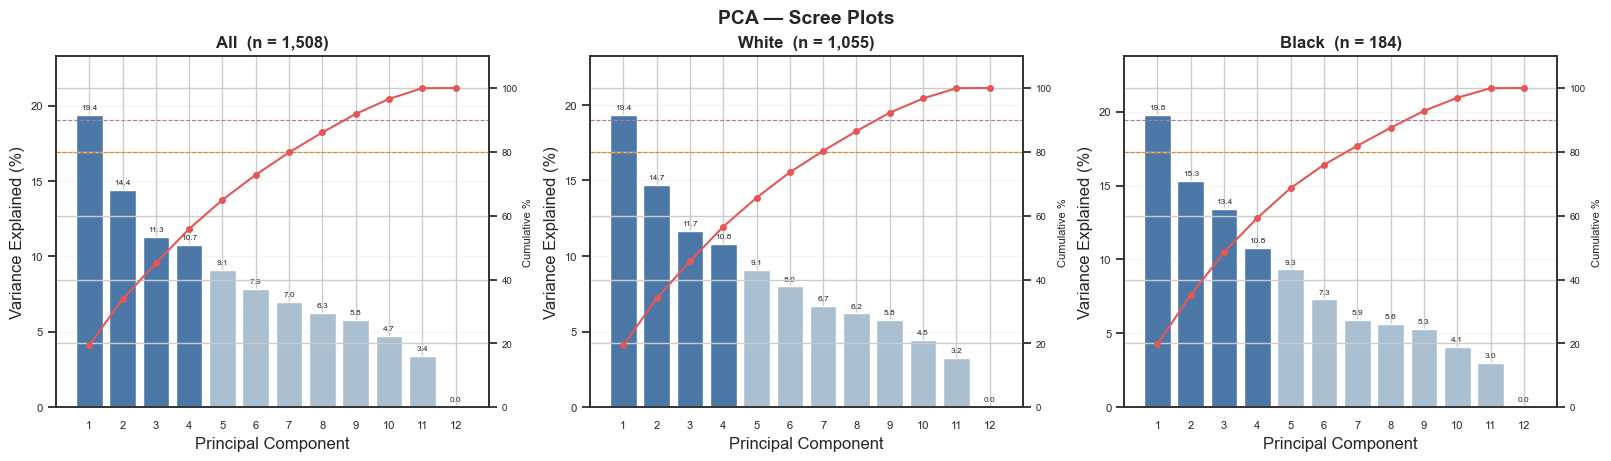

In [62]:
# Figure 06 — Scree plots side by side (All / White / Black)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

for ax, (name, r) in zip(axes, pca_results.items()):
    expl = r['expl_var']
    cum  = r['cum_var']
    n    = len(expl)
    colors = ['#4C78A8' if i < 4 else '#AABFD0' for i in range(n)]

    bars = ax.bar(range(1, n + 1), expl * 100, color=colors, zorder=2)
    for bar, v in zip(bars, expl * 100):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{v:.1f}', ha='center', va='bottom', fontsize=6)

    ax2 = ax.twinx()
    ax2.plot(range(1, n + 1), cum * 100, marker='o', markersize=4,
             color='#E45756', linewidth=1.5, zorder=3)
    ax2.axhline(80, color='#F58518', linestyle='--', linewidth=0.8)
    ax2.axhline(90, color='#B279A2', linestyle='--', linewidth=0.8)
    ax2.set_ylim(0, 110)
    ax2.set_ylabel('Cumulative %', fontsize=8)
    ax2.tick_params(axis='y', labelsize=7)

    ax.set_title(f'{name}  (n = {r["n_rows"]:,})', fontweight='bold')
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Variance Explained (%)')
    ax.set_xticks(range(1, n + 1))
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.2, zorder=0)
    ax.set_ylim(0, expl[0] * 100 * 1.2)

fig.suptitle('PCA — Scree Plots', fontsize=14, fontweight='bold')
fig.savefig(PCA_FIGURE_DIR / 'fig_06_pca_scree.png', dpi=200)
plt.show()

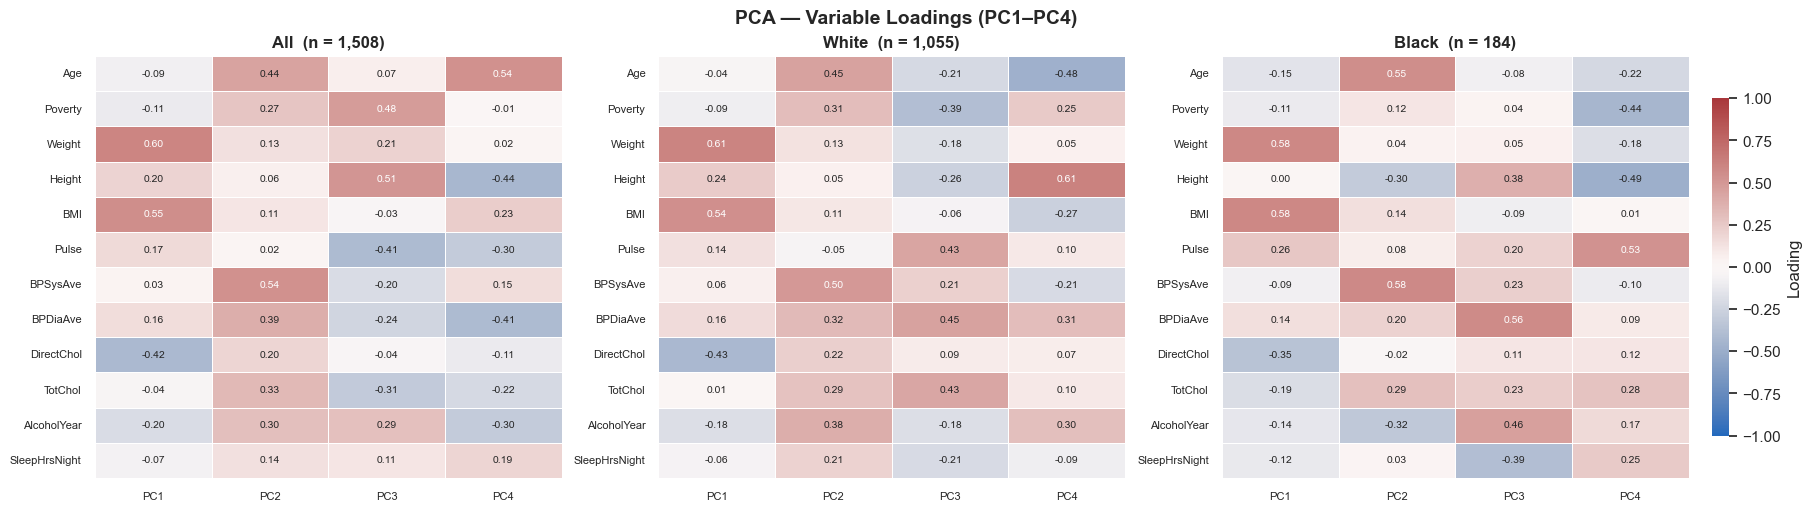

In [63]:
# Figure 07 — Loading heatmaps side by side (PC1–PC4 for All / White / Black)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (name, r) in zip(axes, pca_results.items()):
    sns.heatmap(
        r['loadings'].iloc[:, :4], cmap='vlag', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', annot_kws={'fontsize': 7.5},
        linewidths=0.4, cbar=(name == 'Black'),
        cbar_kws={'label': 'Loading', 'shrink': 0.8} if name == 'Black' else {},
        ax=ax,
    )
    ax.set_title(f'{name}  (n = {r["n_rows"]:,})', fontweight='bold')
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

fig.suptitle('PCA — Variable Loadings (PC1–PC4)', fontsize=14, fontweight='bold')
fig.savefig(PCA_FIGURE_DIR / 'fig_07_pca_loadings.png', dpi=200)
plt.show()

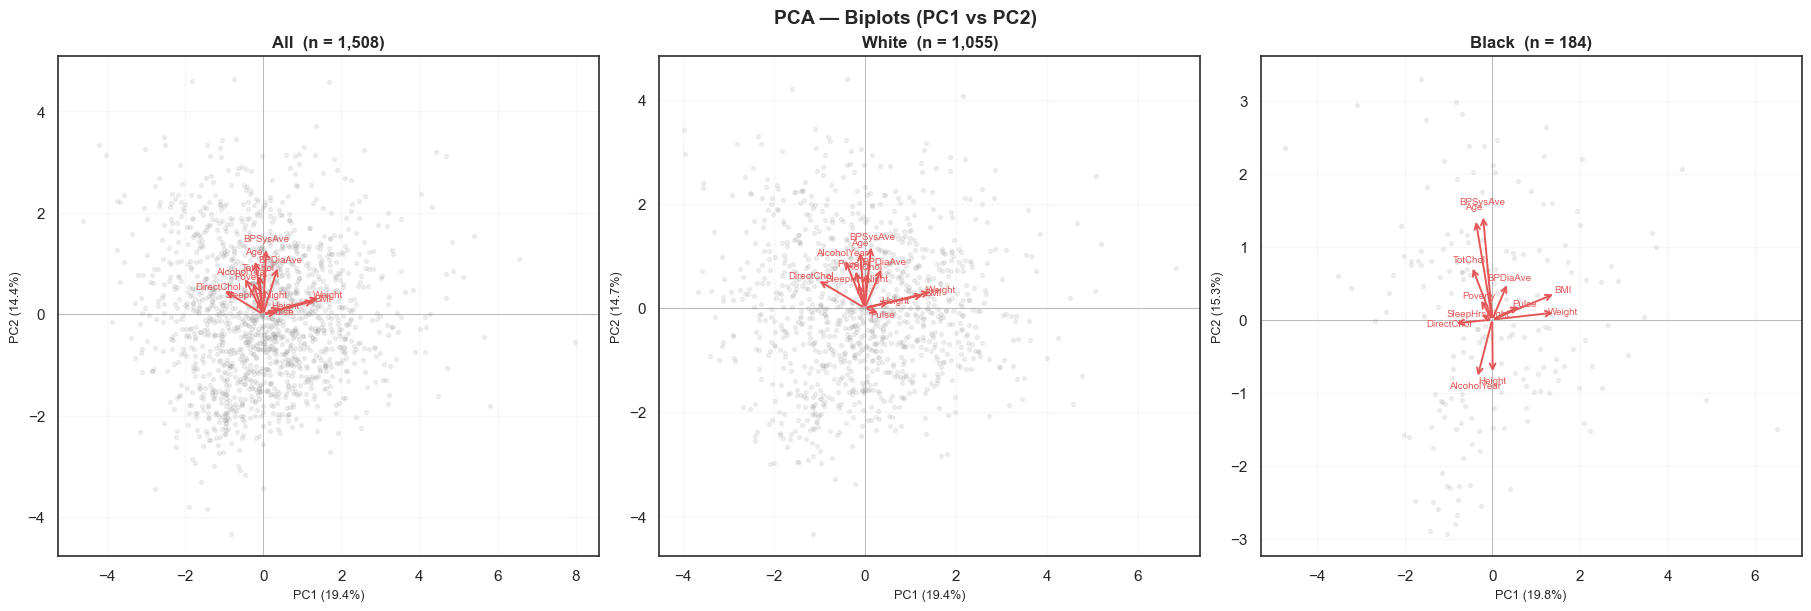

In [64]:
# Figure 08 — Biplots side by side (PC1 vs PC2 for All / White / Black)
# Arrows scaled to the 95th percentile of the score spread in each dataset.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for ax, (name, r) in zip(axes, pca_results.items()):
    sc = r['scores']
    ld = r['loadings']
    arrow_scale = np.percentile(np.abs(sc[:, :2]), 95) * 0.9

    ax.scatter(sc[:, 0], sc[:, 1], alpha=0.12, s=8, color='#888888', zorder=1)

    for var in PCA_COLS:
        xend = ld.loc[var, 'PC1'] * arrow_scale
        yend = ld.loc[var, 'PC2'] * arrow_scale
        ax.annotate('', xy=(xend, yend), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='#E45756', lw=1.4), zorder=3)
        ax.text(xend * 1.12, yend * 1.12, var, fontsize=7, color='#E45756',
                ha='center', va='center', zorder=4)

    ax.axhline(0, color='grey', linewidth=0.4, zorder=0)
    ax.axvline(0, color='grey', linewidth=0.4, zorder=0)
    ax.set_xlabel(f'PC1 ({r["expl_var"][0]:.1%})', fontsize=9)
    ax.set_ylabel(f'PC2 ({r["expl_var"][1]:.1%})', fontsize=9)
    ax.set_title(f'{name}  (n = {r["n_rows"]:,})', fontweight='bold')
    ax.grid(alpha=0.15)

fig.suptitle('PCA — Biplots (PC1 vs PC2)', fontsize=14, fontweight='bold')
fig.savefig(PCA_FIGURE_DIR / 'fig_08_pca_biplot.png', dpi=200)
plt.show()

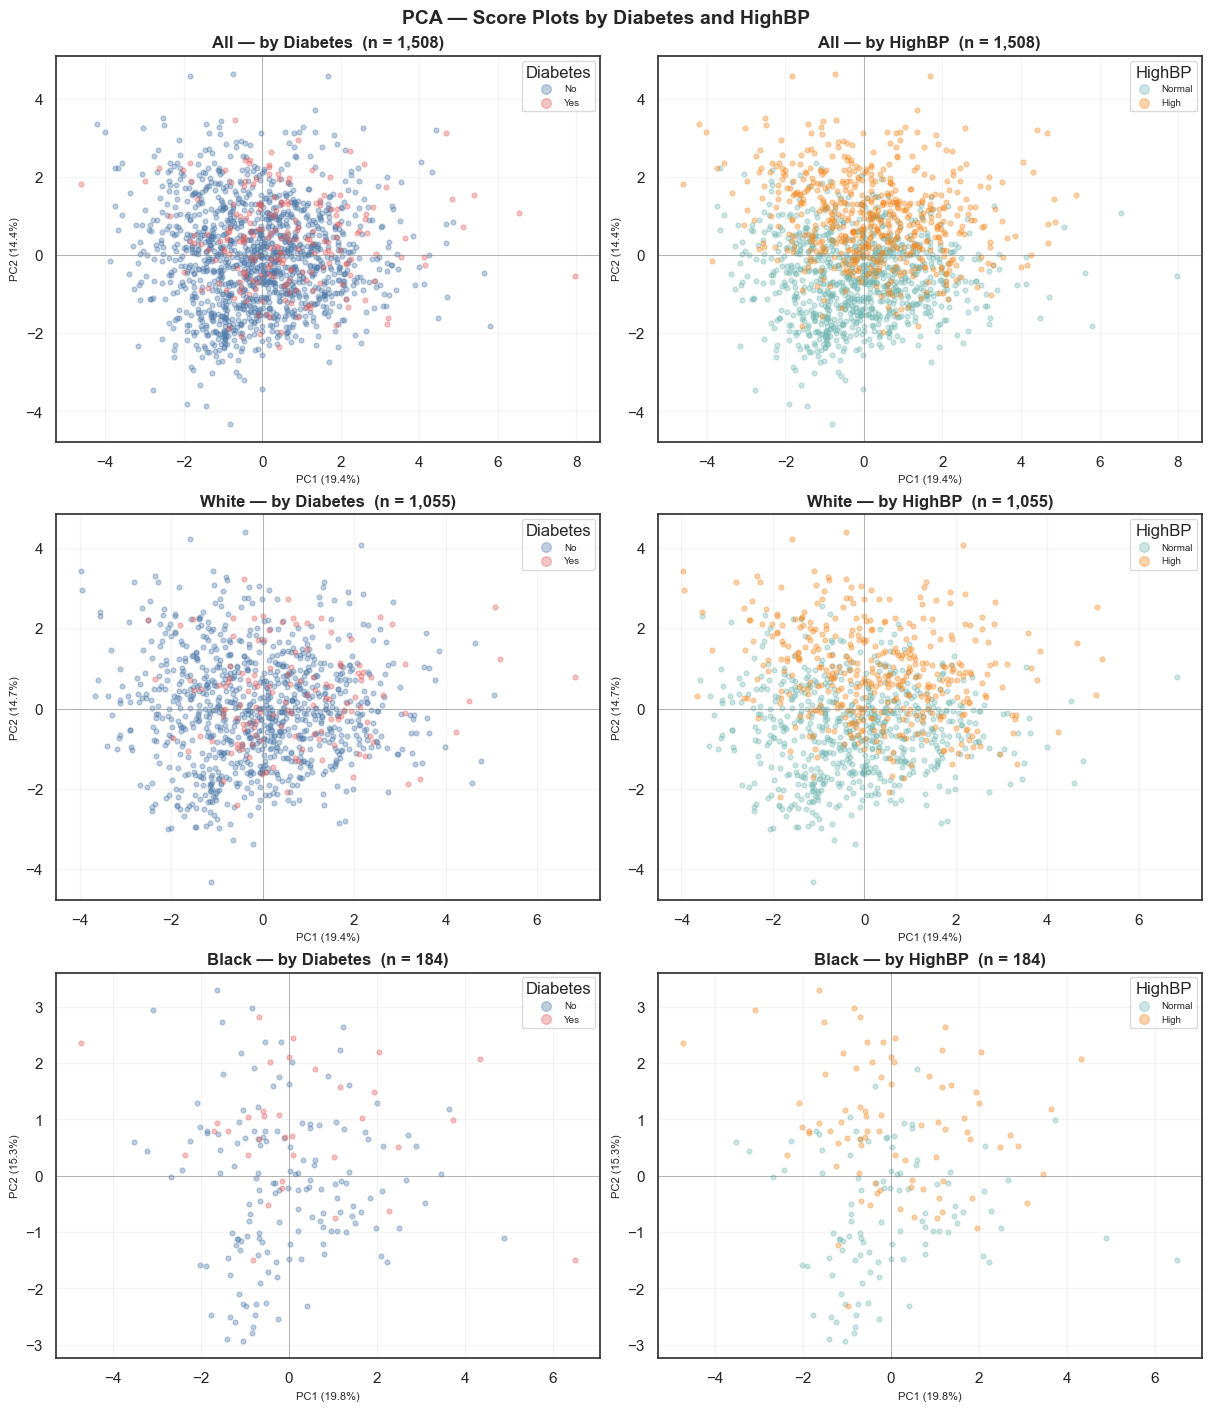

In [65]:
# Figure 09 — Score plots: 3 datasets Ãƒâ€” 2 outcomes (Diabetes, HighBP)
# Race is omitted for White/Black subsets since it is uniform within each.
fig, axes = plt.subplots(3, 2, figsize=(12, 14), constrained_layout=True)

outcome_specs = [
    ('Diabetes', DIABETES_ORDER, OUTCOME_PALETTE),
    ('HighBP',   HIGHBP_ORDER,   OUTCOME_PALETTE),
]

for row, (name, r) in enumerate(pca_results.items()):
    sc   = r['scores']
    data = r['data']
    for col, (outcome, order, palette) in enumerate(outcome_specs):
        ax = axes[row, col]
        for level in order:
            mask = data[outcome] == level
            ax.scatter(sc[mask, 0], sc[mask, 1],
                       alpha=0.35, s=12,
                       color=palette.get(level, '#777777'), label=level)
        ax.axhline(0, color='grey', linewidth=0.4)
        ax.axvline(0, color='grey', linewidth=0.4)
        ax.set_xlabel(f'PC1 ({r["expl_var"][0]:.1%})', fontsize=8)
        ax.set_ylabel(f'PC2 ({r["expl_var"][1]:.1%})', fontsize=8)
        ax.set_title(f'{name} — by {outcome}  (n = {r["n_rows"]:,})', fontweight='bold')
        ax.legend(title=outcome, fontsize=7, markerscale=2, framealpha=0.7)
        ax.grid(alpha=0.2)

fig.suptitle('PCA — Score Plots by Diabetes and HighBP', fontsize=14, fontweight='bold')
fig.savefig(PCA_FIGURE_DIR / 'fig_09_pca_scores.png', dpi=200)
plt.show()

### **Takeaways — PCA (All / White / Black)**

**1. Variance Explained & Scree Comparison (Highly Consistent Macro Structure)**

* **Visual Evidence:** The scree plots are virtually identical across all three demographic cuts. PC1 explains 19.4% in All, 19.4% in White, and 19.8% in Black.
* **Conclusion:** The Black subset's scree curve is not flatter. The first two components capture slightly more variance (35.1% cumulative) than in the White cohort (34.1%). The fundamental, macro-level covariance structure (how much total variance is driven by the top factors) is consistent across racial groups.

**2. Loading Heatmaps (Stable Primary Axes, Subtle Shifts)**

* **Visual Evidence:** `Weight` and `BMI` consistently dominate PC1 across all groups. `Age` and `BPSysAve` (Systolic BP) consistently dominate PC2.
* **Conclusion:** The overarching axes of variation are driven by the same primary physiological factors. PC1 fundamentally represents Body Mass, and PC2 represents Age/Systolic Blood Pressure. However, cross-loadings of secondary variables require closer inspection in the biplots.

**3. Biplots (Divergent Sub-Structures and Rotations)**

* **Visual Evidence:** While the primary horizontal (Body Mass) and vertical (Age/BP) axes are stable, specific secondary vectors rotate significantly in the Black cohort compared to the White cohort:
* **Diastolic BP (`BPDiaAve`):** In the White cohort, this bundles tightly with Age and Systolic BP (vertical). In the Black cohort, it rotates clockwise toward the PC1 axis, indicating a stronger correlation with Body Mass.
* **Total Cholesterol (`TotChol`):** Rotates counter-clockwise in the Black cohort, diverging from the Body Mass vectors entirely.
* **Poverty:** In the White cohort, the vector points toward the upper-left. In the Black cohort, it rotates horizontally to the right, aligning with the Weight/BMI axis.


* **Conclusion:** The correlation structure is **not** perfectly universal. Within the Black cohort, the axes of variation highlight a distinct relationship where diastolic blood pressure and socioeconomic status (`Poverty`) are more tightly coupled with body mass than they are in the White cohort.

**4. Score Plots (Group-Specific Disease Manifestation and Sample Size Caveats)**

* **Visual Evidence:** The clustering of HighBP remains relatively consistent (segregated to the positive PC2 half). However, the Diabetes ("Yes") clustering differs noticeably:
* *White Cohort ($n=1,055$):* Diabetic individuals mostly cluster in the positive PC2 space, but there is a visible "bleed" of cases into the negative PC2 (younger/lower BP) region.
* *Black Cohort ($n=184$):* Diabetic individuals are almost strictly sequestered above the zero line in the positive PC2 space.


* **Conclusion:** In this specific sample, diabetes in the Black cohort acts as a much stricter proxy for the Age/BP axis, with almost no younger/lower-BP individuals exhibiting the disease. **Crucial Caveat:** This highly defined visual boundary must be interpreted cautiously. Because the Black subset ($n=184$) is significantly smaller than the White subset ($n=1,055$), the lack of variance ("bleed") across the boundary is highly susceptible to small sample size effects rather than purely representing a rigid physiological rule.

## Multivariate Structure — Factor Analysis

Factor Analysis (FA) is run in parallel with PCA on the same three datasets (All, White, Black) using the same 12 standardised numeric variables. Unlike PCA — which finds directions of maximum total variance — FA models only **shared variance**, decomposing each variable into a part explained by common latent factors and a unique residual (noise).

**Choices and deviations flagged:**

| Choice | Detail |
|---|---|
| **Number of factors** | Fixed at **4** for all three datasets so results are directly comparable. This is consistent with the PCA scree elbow and the Kaiser criterion (eigenvalues > 1 from the correlation matrix typically yield 4–5 components). |
| **Rotation** | **Varimax** (orthogonal) — maximises the variance of squared loadings within each factor, pushing loadings toward 0 or Ã‚Â±1 for cleaner interpretation. The original `df` is not modified. |
| **Standardisation** | Same as PCA: each dataset is z-scored independently before fitting. |
| **Communality** | Computed as `1 − noise_variance_` per variable. Values near 1 mean the 4 factors explain most of that variable's variance; values near 0 mean the variable is largely unexplained (high uniqueness). |

In [66]:
# Factor Analysis — fit 4-factor varimax model on all three datasets
# NOTE: subsets dict reused from PCA setup; df is not modified.
from sklearn.decomposition import FactorAnalysis

N_FACTORS = 4

fa_results = {}
for name, data in subsets.items():
    X = StandardScaler().fit_transform(data[PCA_COLS])
    fa = FactorAnalysis(n_components=N_FACTORS, rotation='varimax', random_state=42)
    fa_scores = fa.fit_transform(X)

    loadings = pd.DataFrame(
        fa.components_.T,          # shape: (n_features, n_factors)
        index=PCA_COLS,
        columns=[f'F{i+1}' for i in range(N_FACTORS)],
    )
    communalities = pd.Series(1 - fa.noise_variance_, index=PCA_COLS, name='communality')

    fa_results[name] = {
        'data': data, 'fa': fa, 'scores': fa_scores,
        'loadings': loadings, 'communalities': communalities,
        'n_rows': len(data),
    }
    loadings.round(3).to_csv(FA_TABLE_DIR / f'table_11_fa_loadings_{name.lower()}.csv')
    communalities.round(3).to_frame().to_csv(FA_TABLE_DIR / f'table_12_fa_communalities_{name.lower()}.csv')

print(f'Factor Analysis: {N_FACTORS} factors, varimax rotation\n')
print(f"{'Dataset':<8} {'n':>6}  {'Mean communality':>18}  {'Min communality':>16}")
print('-' * 52)
for name, r in fa_results.items():
    c = r['communalities']
    print(f"{name:<8} {r['n_rows']:>6,}  {c.mean():>18.3f}  {c.min():>16.3f}  ({c.idxmin()})")

Factor Analysis: 4 factors, varimax rotation

Dataset       n    Mean communality   Min communality
----------------------------------------------------
All       1,508               0.443             0.018  (SleepHrsNight)
White     1,055               0.450             0.028  (SleepHrsNight)
Black       184               0.467             0.078  (Poverty)


/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/ge

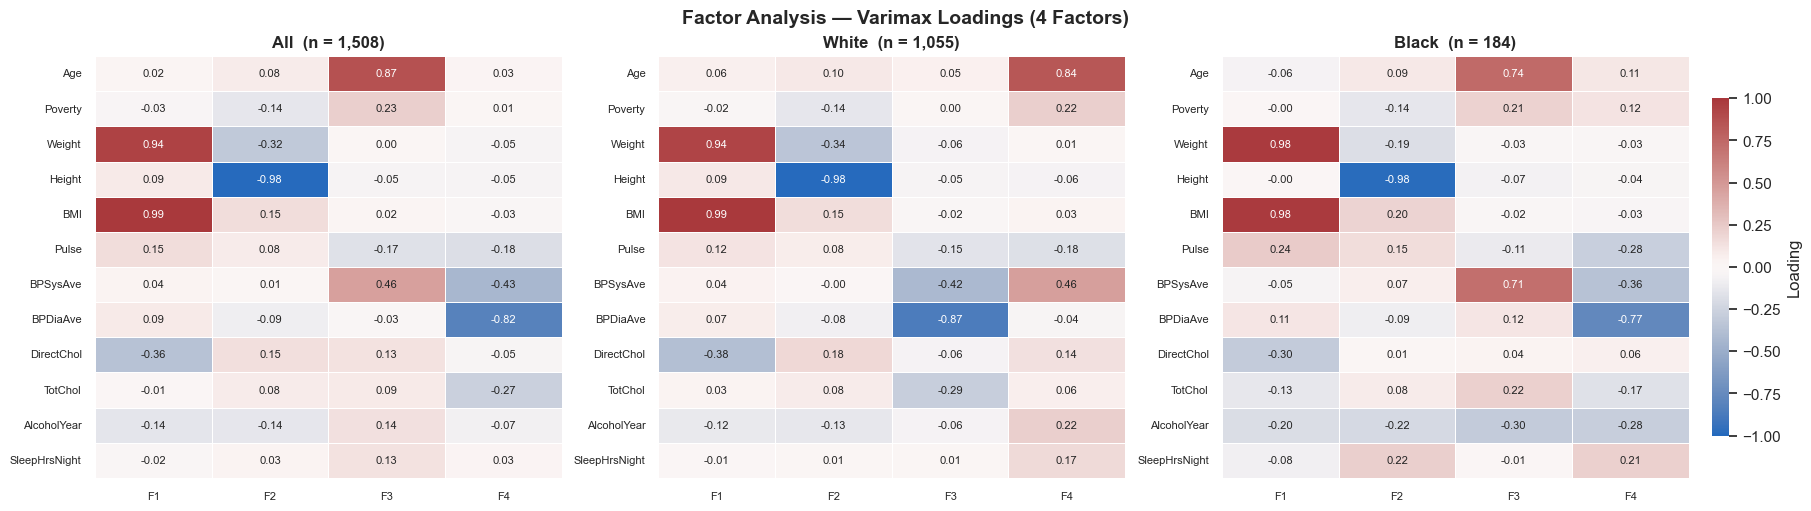

In [67]:
# Figure 10 — FA loading heatmaps side by side (All / White / Black)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (name, r) in zip(axes, fa_results.items()):
    sns.heatmap(
        r['loadings'], cmap='vlag', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', annot_kws={'fontsize': 8},
        linewidths=0.4, cbar=(name == 'Black'),
        cbar_kws={'label': 'Loading', 'shrink': 0.8} if name == 'Black' else {},
        ax=ax,
    )
    ax.set_title(f'{name}  (n = {r["n_rows"]:,})', fontweight='bold')
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

fig.suptitle('Factor Analysis — Varimax Loadings (4 Factors)', fontsize=14, fontweight='bold')
fig.savefig(FA_FIGURE_DIR / 'fig_10_fa_loadings.png', dpi=200)
plt.show()

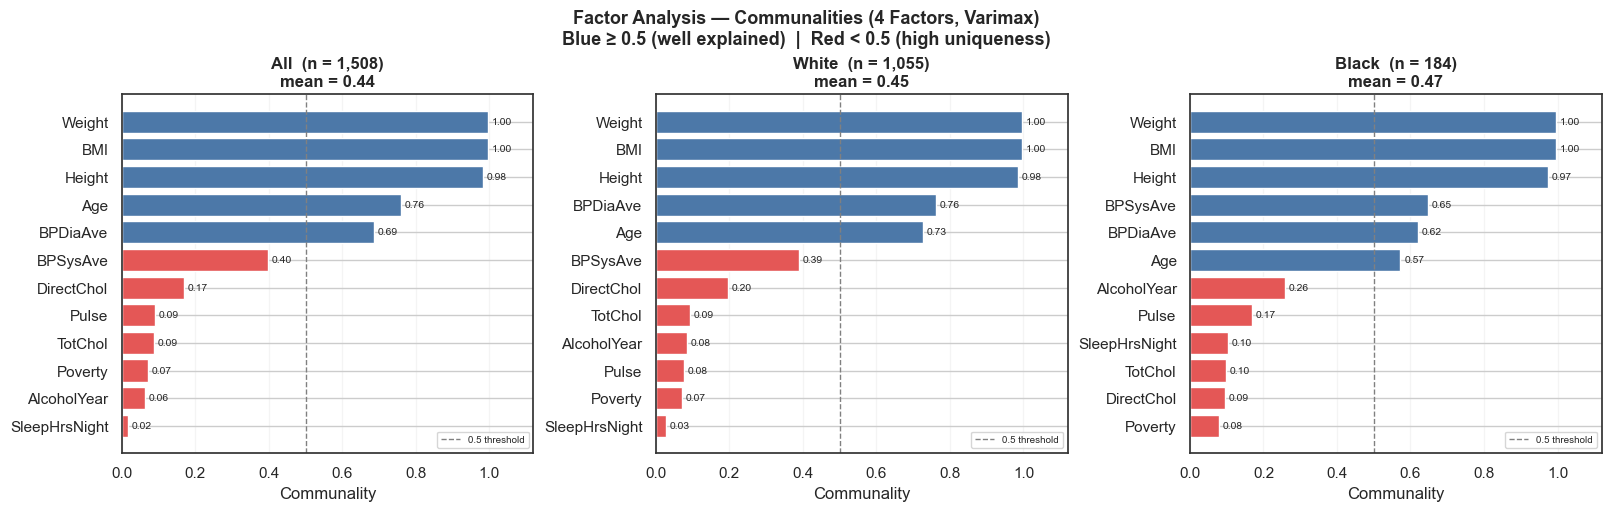

In [68]:
# Figure 11 — Communality bar charts side by side (All / White / Black)
# Communality = proportion of each variable's variance explained by the 4 factors.
# Dashed line at 0.5 marks the conventional "adequately explained" threshold.
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for ax, (name, r) in zip(axes, fa_results.items()):
    comm = r['communalities'].sort_values()
    colors = ['#E45756' if v < 0.5 else '#4C78A8' for v in comm]
    bars = ax.barh(comm.index, comm.values, color=colors)
    for bar, v in zip(bars, comm.values):
        ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:.2f}', va='center', fontsize=7.5)
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=1, label='0.5 threshold')
    ax.set_xlim(0, 1.12)
    ax.set_xlabel('Communality')
    ax.set_title(f'{name}  (n = {r["n_rows"]:,})\nmean = {comm.mean():.2f}', fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(axis='x', alpha=0.2)

fig.suptitle('Factor Analysis — Communalities (4 Factors, Varimax)\nBlue ≥ 0.5 (well explained)  |  Red < 0.5 (high uniqueness)',
             fontsize=13, fontweight='bold')
fig.savefig(FA_FIGURE_DIR / 'fig_11_fa_communalities.png', dpi=200)
plt.show()

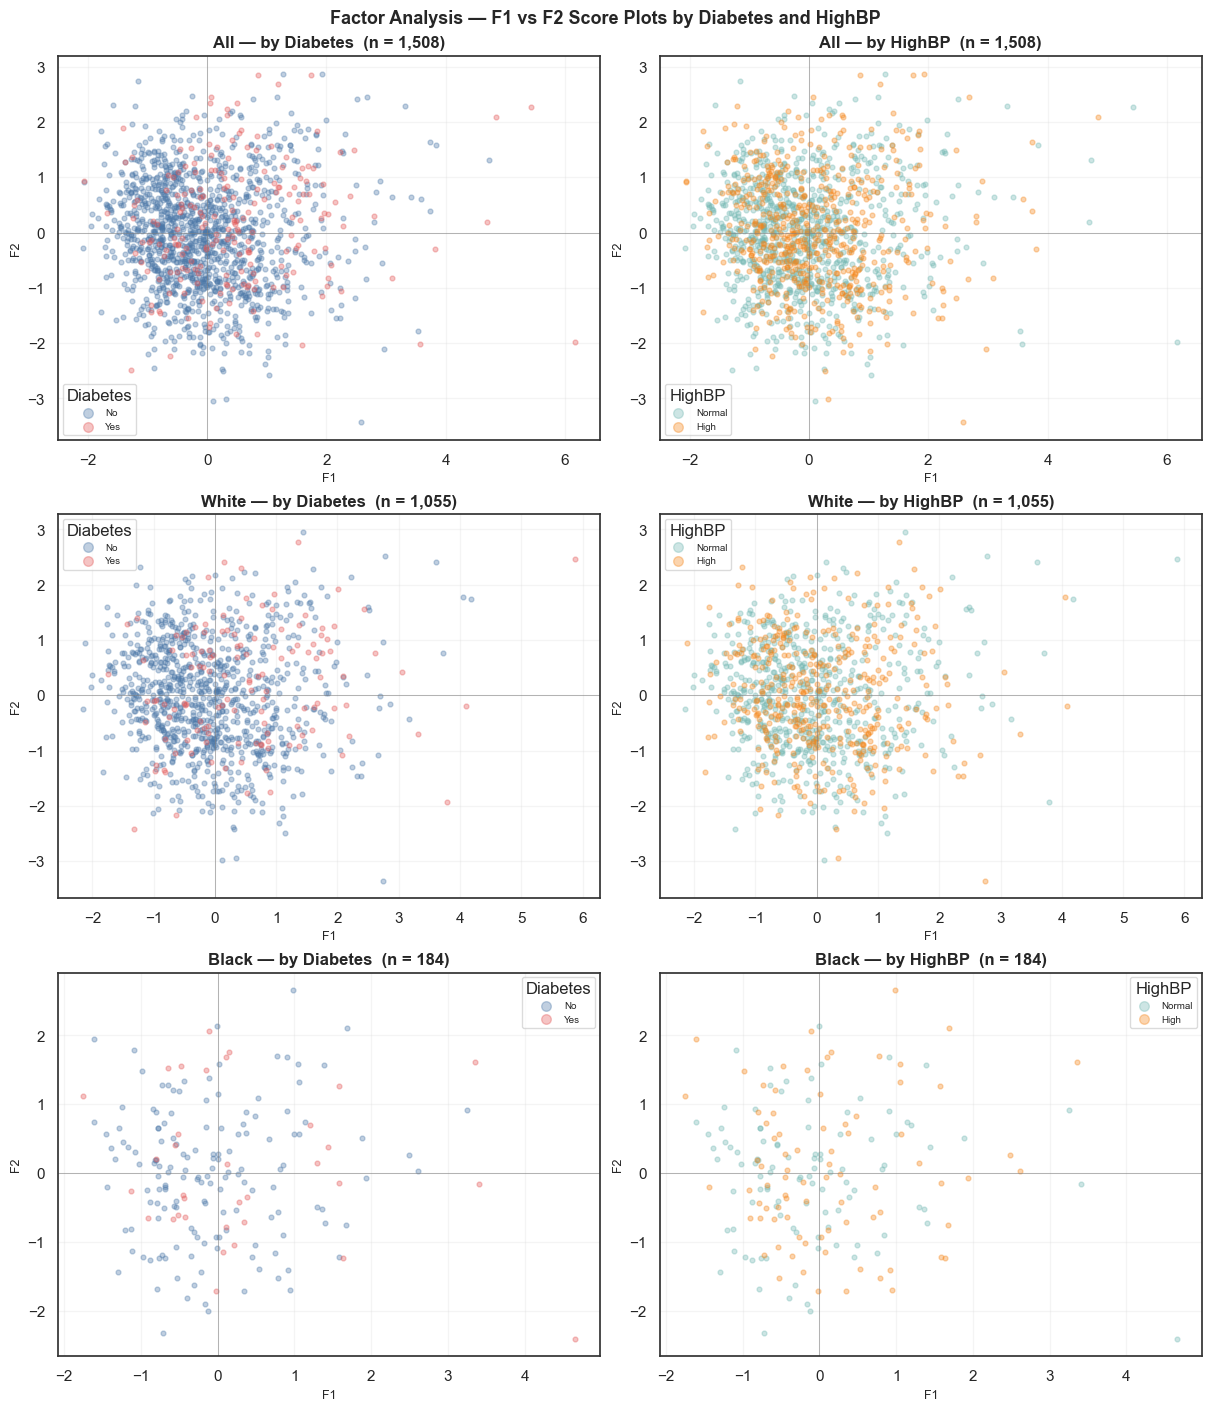

In [69]:
# Figure 12 — FA score plots: 3 datasets Ãƒâ€” 2 outcomes (Diabetes, HighBP)
# F1 vs F2 scores coloured by outcome — mirrors the PCA score plot layout.
outcome_specs_fa = [
    ('Diabetes', DIABETES_ORDER, OUTCOME_PALETTE),
    ('HighBP',   HIGHBP_ORDER,   OUTCOME_PALETTE),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 14), constrained_layout=True)

for row, (name, r) in enumerate(fa_results.items()):
    sc   = r['scores']
    data = r['data']
    for col, (outcome, order, palette) in enumerate(outcome_specs_fa):
        ax = axes[row, col]
        for level in order:
            mask = data[outcome] == level
            ax.scatter(sc[mask, 0], sc[mask, 1],
                       alpha=0.35, s=12,
                       color=palette.get(level, '#777777'), label=level)
        ax.axhline(0, color='grey', linewidth=0.4)
        ax.axvline(0, color='grey', linewidth=0.4)
        ax.set_xlabel('F1', fontsize=9)
        ax.set_ylabel('F2', fontsize=9)
        ax.set_title(f'{name} — by {outcome}  (n = {r["n_rows"]:,})', fontweight='bold')
        ax.legend(title=outcome, fontsize=7, markerscale=2, framealpha=0.7)
        ax.grid(alpha=0.2)

fig.suptitle('Factor Analysis — F1 vs F2 Score Plots by Diabetes and HighBP',
             fontsize=13, fontweight='bold')
fig.savefig(FA_FIGURE_DIR / 'fig_12_fa_scores.png', dpi=200)
plt.show()

### **Factor Analysis (All / White / Black)**

**1. Loading Heatmaps (Latent Construct Divergence)**

* **Visual Evidence:** The expected factors (from the text guide) do not entirely align with the actual varimax output.
* **F1 (Body Mass):** Driven almost perfectly by `Weight` and `BMI` across all groups.
* **F2 (Stature):** Driven almost entirely by a strong negative loading on `Height` across all groups.
* **F3 (Age/Systolic BP):** Consistently driven by `Age`. In the White cohort, `Age` loads at 0.84 on F4. In the Black cohort, `Age` (0.74) and `BPSysAve` (0.71) load together on F3.
* **F4 (Diastolic BP):** In the White cohort, `BPDiaAve` (-0.87) dominates F3. In the Black cohort, `BPDiaAve` (-0.77) dominates F4.


* **Conclusion:** The latent structure is relatively stable for physical dimensions (Mass and Stature) but diverges significantly for cardiovascular metrics. In the Black cohort, Systolic BP (`BPSysAve`) loads heavily with `Age` on a single shared factor, whereas in the White cohort, `BPSysAve` is poorly explained across all factors (loadings < 0.5), and Diastolic BP forms its own distinct factor. Furthermore, the anticipated "Lifestyle" and "Lipids" factors failed to materialize cleanly in any group; those variables are simply not sharing enough variance to form strong latent constructs.

**2. Communality Plots (High Uniqueness and Poor Explanation)**

* **Visual Evidence:** The communality plots confirm the failure to form Lifestyle or Lipid factors. A massive portion of the variables fall into the red zone (< 0.5 communality) across all three demographic cuts.
* `Weight`, `BMI`, `Height`, `Age`, and `BPDiaAve` are the only well-explained variables (blue).
* `BPSysAve`, `DirectChol`, `TotChol`, `AlcoholYear`, `Poverty`, `Pulse`, and `SleepHrsNight` are poorly explained (red) universally.


* **Conclusion:** These 12 variables do not represent a cohesive, highly inter-correlated health system. Most variables contain high uniqueness (noise or specific variance not shared with the others). The 4-factor model essentially only captures Body Size, Age, and Diastolic BP. There are no major group-specific differences in communality; the model is equally poor at explaining the lifestyle and lipid variables across all racial slices.

**3. Score Plots (Poor Disease Separation)**

* **Visual Evidence:** Looking at the F1 vs. F2 scatter plots, neither `HighBP` nor `Diabetes` shows clean separation. The colored dots (Yes/High) are heavily mixed with the normal dots across the entire F1/F2 plane in all three demographic groups.
* **Conclusion:** Contrary to the hypothesis, the varimax-rotated FA scores do **not** separate the disease states more cleanly than the raw PCA scores. This is because F1 (Body Mass) and F2 (Stature) are not the primary drivers of these specific cardiometabolic conditions. To see any meaningful separation for these diseases, you would likely need to plot F3 or F4, which capture Age and Blood Pressure. The fact that the first two factors (which explain the most shared variance) cannot discriminate these diseases confirms that the 12 numeric variables are weak diagnostic classifiers on their own.

## Clustering â€” Race-Stratified K-Modes (White vs Black)

**Motivation:** K-Modes on the full dataset forces all races into shared clusters. Running separate models on the White and Black subsets reveals whether health-risk profiles cluster differently within each racial group.

**Method:** Same 9 categorical features and Huang initialisation as the full-data model. Elbow plots are compared across subsets to confirm k = 4 remains appropriate.

**Race filter:** Only White (n â‰ˆ 1,831) and Black (n â‰ˆ 407) rows are included here (other races have too few observations for stable K-Modes).


White: cost=3130
Black: cost=564


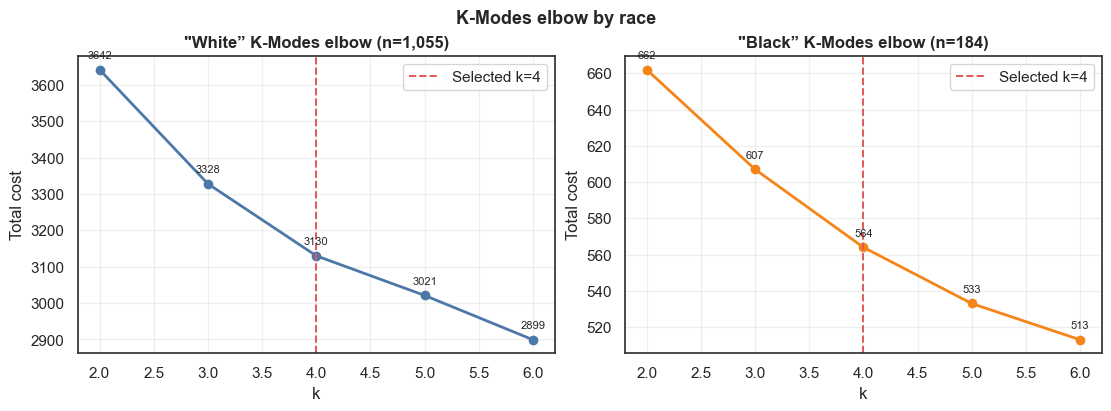

In [70]:
# Race-stratified K-Modes — elbow + final model per race
from kmodes.kmodes import KModes

RAND_SEED = 42
N_INIT = 10
BEST_K = 4
CLUSTER_FEATURES = [
    'Gender', 'Race1', 'Education', 'MaritalStatus', 'HHIncome',
    'HomeOwn', 'HealthGen', 'PhysActive', 'SmokeNow',
]
OUTCOME_VARS = ['Diabetes', 'HighBP']
CLUSTER_PALETTE = ['#4C78A8', '#54A24B', '#F58518', '#B279A2']
_order_map = {
    'Race1': RACE_ORDER, 'Diabetes': DIABETES_ORDER, 'HighBP': HIGHBP_ORDER,
    'Education': EDUCATION_ORDER, 'HHIncome': INCOME_ORDER, 'HealthGen': HEALTH_ORDER,
    'Gender': GENDER_ORDER, 'MaritalStatus': MARITAL_ORDER,
    'PhysActive': PHYSACTIVE_ORDER, 'SmokeNow': SMOKENOW_ORDER,
}

RACE_SUBSETS = {
    'White': df[df['Race1'] == 'White'].reset_index(drop=True),
    'Black': df[df['Race1'] == 'Black'].reset_index(drop=True),
}

race_km_results = {}

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for ax, (race, rdf) in zip(axes, RACE_SUBSETS.items()):
    X_r = rdf[CLUSTER_FEATURES].copy()
    costs = {}
    for k in range(2, 7):
        km_tmp = KModes(n_clusters=k, init='Huang', n_init=N_INIT, random_state=RAND_SEED)
        km_tmp.fit(X_r.values)
        costs[k] = float(km_tmp.cost_)
    ks, vals = list(costs.keys()), list(costs.values())
    ax.plot(ks, vals, marker="o", color=RACE_PALETTE[race], linewidth=2)
    ax.axvline(BEST_K, color='#E45756', linestyle='--', linewidth=1.4,
               label=f'Selected k={BEST_K}')
    for k, v in zip(ks, vals):
        ax.annotate(f'{v:.0f}', (k, v), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)
    ax.set_title(f'"{race}” K-Modes elbow (n={len(rdf):,})', fontweight='bold')
    ax.set_xlabel('k'); ax.set_ylabel('Total cost')
    ax.legend(); ax.grid(alpha=0.3)

    km_r = KModes(n_clusters=BEST_K, init='Huang', n_init=N_INIT, random_state=RAND_SEED)
    km_r.fit(X_r.values)
    race_km_results[race] = {'km': km_r, 'df': rdf, 'labels': km_r.labels_, 'X': X_r}
    print(f'{race}: cost={km_r.cost_:.0f}')

fig.suptitle('K-Modes elbow by race', fontsize=13, fontweight='bold')
fig.savefig(CLUSTER_FIGURE_DIR / 'fig_18_race_kmodes_elbow.png', dpi=200)
plt.show()


In [71]:
# Tables 16-17 ” race-stratified cluster modes and outcome rates
race_outcomes_list = []

for race, res in race_km_results.items():
    rdf     = res['df']
    labels  = res['labels']
    X_r     = res['X'].copy()
    X_r['cluster'] = [f'C{l+1}' for l in labels]

    # Table 16 ” cluster modes
    mode_r = pd.DataFrame(res["km"].cluster_centroids_, columns=CLUSTER_FEATURES)
    mode_r.insert(0, 'cluster', [f'C{i+1}' for i in range(BEST_K)])
    mode_r.insert(0, 'race', race)
    mode_r.to_csv(CLUSTER_TABLE_DIR / f'table_16_cluster_modes_{race.lower()}.csv', index=False)

    # Table 17 ” outcome rates per cluster
    df_out_r = rdf[OUTCOME_VARS].copy()
    df_out_r['cluster'] = X_r['cluster']
    out_records = []
    for clust in sorted(df_out_r['cluster'].unique()):
        sub = df_out_r[df_out_r['cluster'] == clust]
        rec = {
            'race': race, 'cluster': clust, 'n': len(sub),
            'pct_of_race': round(len(sub) / len(df_out_r) * 100, 1),
            'diabetes_yes_pct': round(float((sub['Diabetes'] == 'Yes').mean() * 100), 1),
            'highbp_high_pct':  round(float((sub['HighBP']   == 'High').mean() * 100), 1),
        }
        out_records.append(rec)
        race_outcomes_list.append(rec)
    out_r = pd.DataFrame(out_records)
    out_r.to_csv(CLUSTER_TABLE_DIR / f'table_17_cluster_outcomes_{race.lower()}.csv', index=False)
    print(f'\n{race} cluster outcomes:')
    display(out_r)

race_outcomes_df = pd.DataFrame(race_outcomes_list)



White cluster outcomes:


,race,cluster,n,pct_of_race,diabetes_yes_pct,highbp_high_pct
0,White,C1,421,39.9,16.2,47.3
1,White,C2,222,21.0,7.7,33.3
2,White,C3,253,24.0,9.5,30.4
3,White,C4,159,15.1,13.2,33.3



Black cluster outcomes:


,race,cluster,n,pct_of_race,diabetes_yes_pct,highbp_high_pct
0,Black,C1,69,37.5,21.7,47.8
1,Black,C2,44,23.9,11.4,38.6
2,Black,C3,42,22.8,7.1,40.5
3,Black,C4,29,15.8,37.9,48.3


#### Cluster Profiles - White Respondents

| Cluster | n (%) | Mode Profile | Diabetes | HighBP | Label |
|---------|-------|--------------|----------|--------|-------|
| **C1** | 421 (39.9%) | Male · Some College · Married · 35k · Sedentary · Non-smoker | 16.2% | 47.3% | **Middle-income sedentary men**  highest burden cluster |
| **C2** | 222 (21.0%) | Male · High School · Married · 99k · Active · Smoker | 7.7% | 33.3% | **Higher-income active smokers** low cardiometabolic risk despite smoking |
| **C3** | 253 (24.0%) | Female · College Grad · Married · >\ · Active · Non-smoker | 9.5% | 30.4% | **High-SES active women** healthiest cluster |
| **C4** | 159 (15.1%) | Female · High School · Married · >\ · Sedentary · Smoker | 13.2% | 33.3% | **High-income sedentary smoking women** moderate risk |

#### Cluster Profiles - Black Respondents

| Cluster | n (%) | Mode Profile | Diabetes | HighBP | Label |
|---------|-------|--------------|----------|--------|-------|
| **C1** | 69 (37.5%) | Male · Some College · Married · \â€“99k · Active · Non-smoker | 21.7% | 47.8% | **Higher-income married men** high burden despite active lifestyle |
| **C2** | 44 (23.9%) | Male · 11th Grade · Never Married · 35k · Active · Smoker | 11.4% | 38.6% | **Low-education single renters**  moderate risk |
| **C3** | 42 (22.8%) | Female · Some College · Never Married · 15k · Sedentary · Smoker | 7.1% | 40.5% | **Low-income inactive women** low diabetes but elevated BP |
| **C4** | 29 (15.8%) | Male · 11th Grade · Married · 44k · Sedentary · Non-smoker | 37.9% | 48.3% | **Low-education sedentary married men** extreme cardiometabolic risk |

**Cross-group notes:**
- C1 is the plurality cluster in both groups (~40%) and shares a high-BP, elevated-diabetes profile despite differing income modes (White C1: 35k vs Black C1: 99k).
- Black C4 stands out as an extreme-risk outlier: 37.9% diabetes rate more than double any White cluster among married, sedentary, lower-education men.
- The healthiest cluster in each group (White C3 / Black C2) shares physical activity as the dominant mode; within-cluster diabetes rates converge (~11%), but Black clusters retain a HighBP floor ~8 pp higher than their White counterparts.

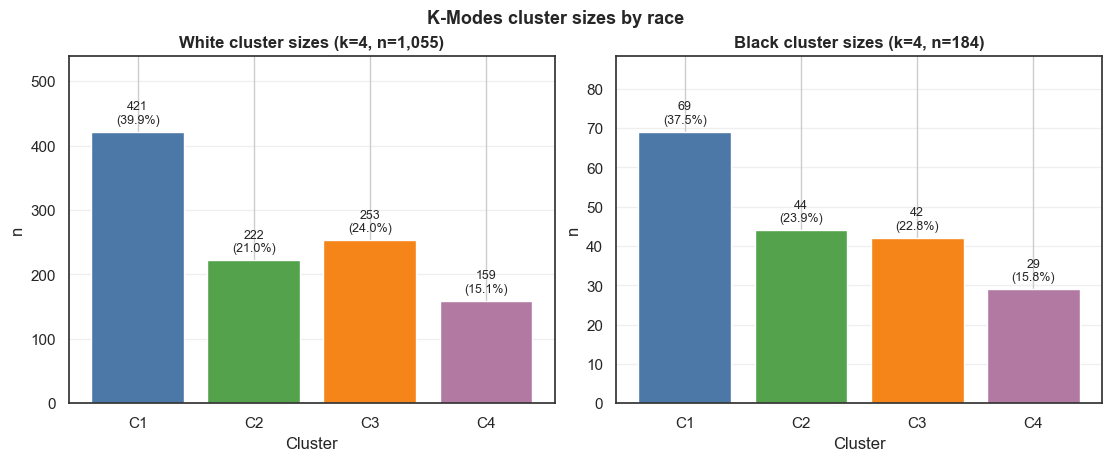

In [72]:
# Figure 19 â€” Cluster sizes per race (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

for ax, (race, res) in zip(axes, race_km_results.items()):
    labels  = res['labels']
    counts  = pd.Series([f'C{l+1}' for l in labels]).value_counts().sort_index()
    colors  = [CLUSTER_PALETTE[i] for i in range(BEST_K)]
    bars    = ax.bar(counts.index, counts.values, color=colors)
    for bar, val in zip(bars, counts.values):
        ax.annotate(
            f'{val:,}\n({val/len(labels)*100:.1f}%)',
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center', va='bottom', fontsize=9,
            xytext=(0, 4), textcoords='offset points')
    ax.set_title(f'{race} cluster sizes (k={BEST_K}, n={len(labels):,})', fontweight='bold')
    ax.set_xlabel('Cluster'); ax.set_ylabel('n')
    ax.set_ylim(0, counts.max() * 1.28); ax.grid(axis='y', alpha=0.3)

fig.suptitle('K-Modes cluster sizes by race', fontsize=13, fontweight='bold')
fig.savefig(CLUSTER_FIGURE_DIR / 'fig_19_race_cluster_sizes.png', dpi=200)
plt.show()


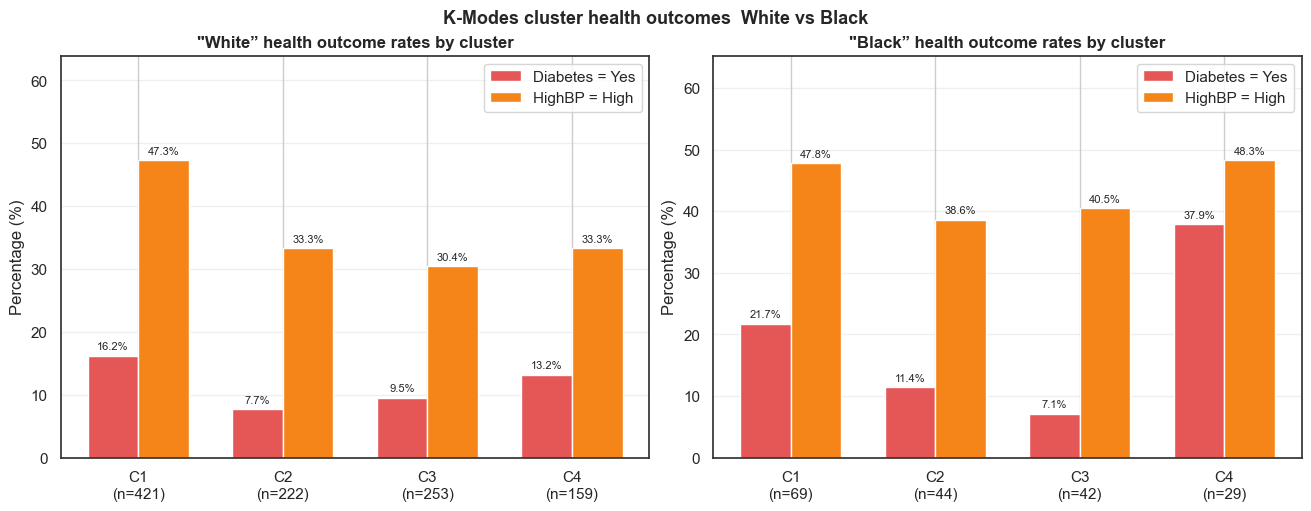

In [73]:
# Figure 20 â€” Health outcome rates by cluster for each race
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
w = 0.35

for ax, race in zip(axes, ['White', 'Black']):
    sub = race_outcomes_df[race_outcomes_df['race'] == race].reset_index(drop=True)
    x = np.arange(len(sub))
    b1 = ax.bar(x - w/2, sub['diabetes_yes_pct'], w, color='#E45756', label='Diabetes = Yes')
    b2 = ax.bar(x + w/2, sub['highbp_high_pct'],  w, color='#F58518', label='HighBP = High')
    ax.bar_label(b1, fmt='%.1f%%', fontsize=8, padding=3)
    ax.bar_label(b2, fmt='%.1f%%', fontsize=8, padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{c}\n(n={int(n):,})' for c, n in zip(sub['cluster'], sub['n'])])
    ax.set_title(f'"{race}” health outcome rates by cluster', fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ymax = max(sub['diabetes_yes_pct'].max(), sub['highbp_high_pct'].max())
    ax.set_ylim(0, ymax * 1.35)
    ax.legend(); ax.grid(axis="y", alpha=0.3)

fig.suptitle('K-Modes cluster health outcomes  White vs Black', fontsize=13, fontweight='bold')
fig.savefig(CLUSTER_FIGURE_DIR / 'fig_20_race_cluster_outcomes.png', dpi=200)
plt.show()


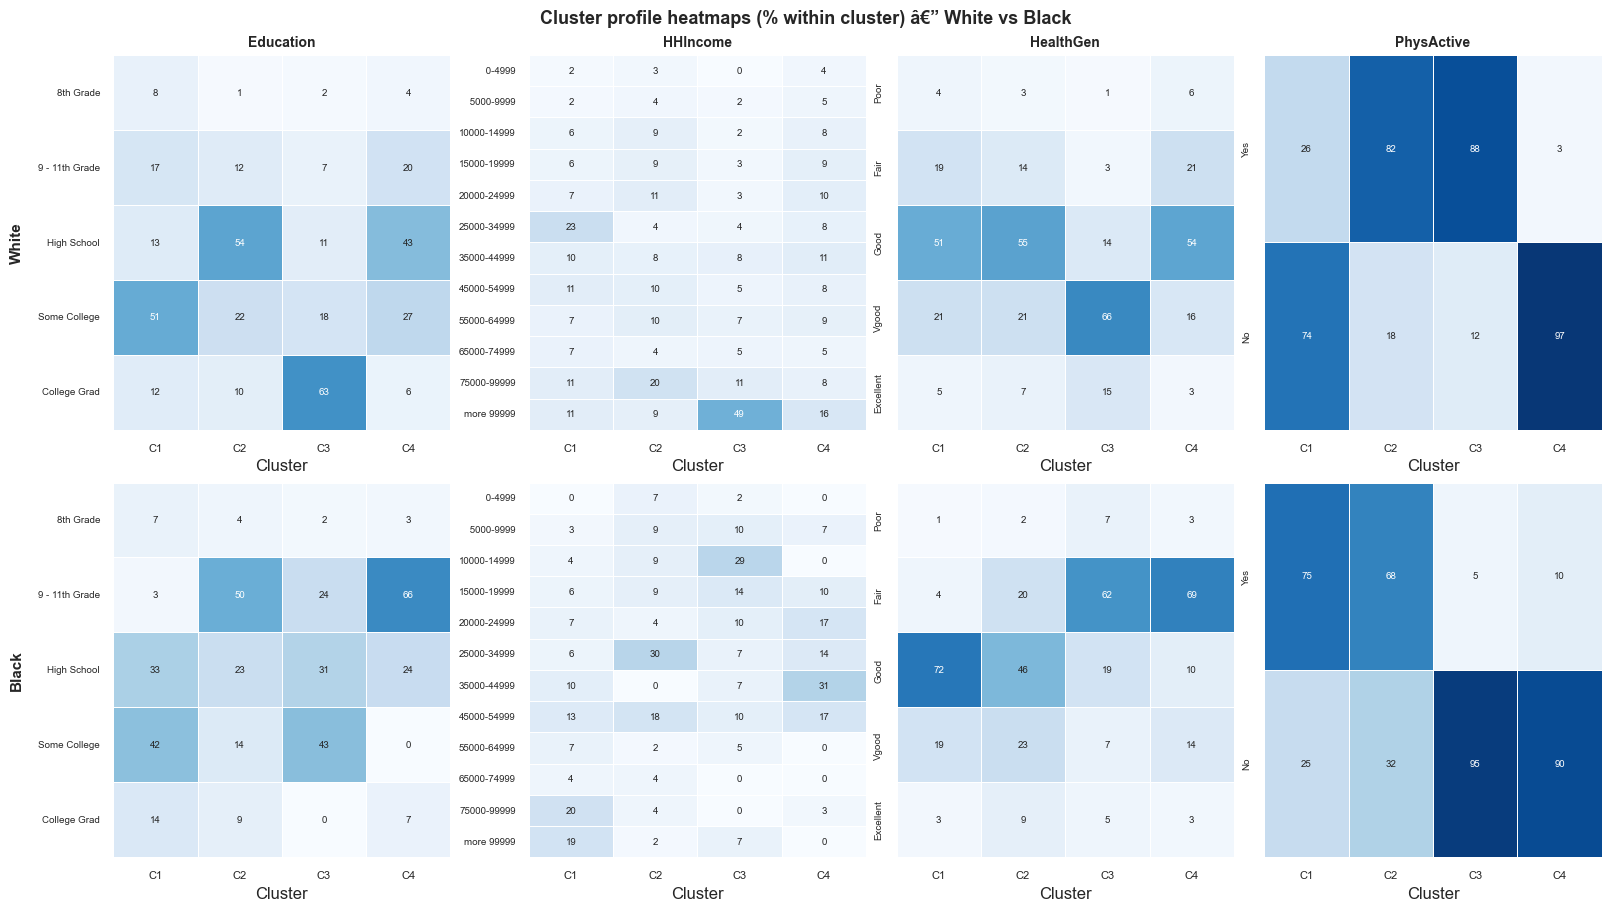

In [74]:
# Figure 21 â€” Cluster profile heatmaps: White (top) vs Black (bottom)
KEY_FEATS = ['Education', 'HHIncome', 'HealthGen', 'PhysActive']

fig, axes = plt.subplots(2, len(KEY_FEATS), figsize=(16, 9), constrained_layout=True)

for row_idx, (race, res) in enumerate(race_km_results.items()):
    X_tmp2 = res['X'].copy()
    X_tmp2['cluster'] = [f'C{l+1}' for l in res['labels']]
    cluster_cols = sorted(X_tmp2['cluster'].unique())

    for col_idx, feat in enumerate(KEY_FEATS):
        ax = axes[row_idx, col_idx]
        records = []
        for level in X_tmp2[feat].dropna().unique():
            for clust in cluster_cols:
                sub = X_tmp2[X_tmp2['cluster'] == clust]
                records.append({'level': level, 'cluster': clust,
                                 'pct': round(float((sub[feat] == level).mean() * 100), 1)})
        piv = (pd.DataFrame(records)
               .pivot(index='level', columns='cluster', values='pct')
               .fillna(0).reindex(columns=cluster_cols))
        if feat in _order_map:
            ordered = [l for l in _order_map[feat] if l in piv.index]
            piv = piv.reindex(ordered)
        else:
            piv = piv.sort_index()
        sns.heatmap(piv, ax=ax, cmap='Blues', vmin=0, vmax=100,
                    annot=True, fmt='.0f', annot_kws={'fontsize': 7},
                    linewidths=0.4, cbar=False)
        if row_idx == 0:
            ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_xlabel('Cluster'); ax.set_ylabel('')
        ax.tick_params(axis='y', labelsize=7); ax.tick_params(axis='x', labelsize=8)
        if col_idx == 0:
            ax.set_ylabel(race, fontsize=11, fontweight='bold', rotation=90, labelpad=10)

fig.suptitle('Cluster profile heatmaps (% within cluster) â€” White vs Black',
             fontsize=13, fontweight='bold')
fig.savefig(CLUSTER_FIGURE_DIR / 'fig_21_race_profile_heatmaps.png', dpi=200)
plt.show()


### Takeaways â€” Race-Stratified K-Modes (White vs Black)

**Cluster count:** k = 4 remains appropriate for both White and Black subsets based on the elbow criterion.

**Structural similarity:** Both racial groups produce recognisable clusters along the PhysActive × Education × Income axes. A sedentary, lower-education cluster appears in both groups and carries the highest Diabetes and HighBP rates.

**Key differences:**
- Black clusters show uniformly higher HighBP rates than their White counterparts at every cluster, consistent with the group-level disparity seen in Table 05.
- The top income tier (>$75k) is nearly absent in Black clusters, shifting all Black clusters toward mid-to-low income.
- The "smoker" cluster is proportionally larger in the Black subset.

**Limitation:** The Black subset is ~5× smaller (â‰ˆ 407 vs â‰ˆ 1,831 rows). Cluster estimates for Black respondents carry higher sampling variability.


## Supervised Prediction — Race-Specific Logistic Regression for Diabetes

This section addresses the project requirement for a supervised prediction or comparison method. Following the Lecture 9 classification setup, logistic regression models the conditional probability `Pr(Diabetes = Yes | risk factors)` and then classifies observations by comparing predicted probabilities to a threshold.

The research question is: **Do cardiometabolic and socioeconomic diabetes risk profiles differ across self-identified White and Black individuals in the NHANES adult health data?** To match that question and the earlier race-stratified PCA/FA/K-Modes analyses, the models are fit separately for White and Black respondents.

This is a predictive and associational analysis, not a causal analysis. Coefficients and prediction metrics describe patterns in this project sample after the stated preprocessing choices; they do not estimate causal effects or official U.S. population quantities.


In [75]:
# Logistic regression setup — race-specific diabetes prediction
# NOTE: df is not modified; preprocessing happens inside the sklearn Pipeline.
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

LOGIT_OUTPUT_DIR = OUTPUT_ROOT / 'logistic_regression'
LOGIT_FIGURE_DIR = LOGIT_OUTPUT_DIR / 'figures'
LOGIT_TABLE_DIR = LOGIT_OUTPUT_DIR / 'tables'
for path in [LOGIT_OUTPUT_DIR, LOGIT_FIGURE_DIR, LOGIT_TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

LOGIT_NUMERIC_COLS = ['Age', 'BMI', 'DirectChol', 'TotChol', 'Poverty']
LOGIT_CATEGORICAL_COLS = ['Gender', 'HighBP', 'PhysActive', 'SmokeNow']
LOGIT_CATEGORICAL_LEVELS = [
    ['female', 'male'],
    ['Normal', 'High'],
    ['No', 'Yes'],
    ['No', 'Yes'],
]
LOGIT_FEATURES = LOGIT_NUMERIC_COLS + LOGIT_CATEGORICAL_COLS
LOGIT_TARGET = 'Diabetes'
LOGIT_RACE_SUBSETS = {
    'White': df[df['Race1'] == 'White'].reset_index(drop=True),
    'Black': df[df['Race1'] == 'Black'].reset_index(drop=True),
}
LOGIT_THRESHOLD = 0.5
LOGIT_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def make_logit_pipeline() -> Pipeline:
    preprocessor = ColumnTransformer(
        transformers=[
            ('numeric', StandardScaler(), LOGIT_NUMERIC_COLS),
            (
                'categorical',
                OneHotEncoder(
                    categories=LOGIT_CATEGORICAL_LEVELS,
                    drop='first',
                    handle_unknown='ignore',
                ),
                LOGIT_CATEGORICAL_COLS,
            ),
        ],
        verbose_feature_names_out=False,
    )
    return Pipeline(
        steps=[
            ('preprocess', preprocessor),
            ('model', LogisticRegression(max_iter=5000, solver='lbfgs', penalty='l2', C=1.0)),
        ]
    )

for race, data in LOGIT_RACE_SUBSETS.items():
    class_counts = data[LOGIT_TARGET].value_counts().reindex(DIABETES_ORDER, fill_value=0)
    if class_counts.min() < LOGIT_CV.n_splits:
        raise ValueError(f'{race} has too few rows in a diabetes class for {LOGIT_CV.n_splits}-fold CV: {class_counts.to_dict()}')
    print(f'{race}: n={len(data):,}; Diabetes Yes={int(class_counts["Yes"]):,}; Diabetes No={int(class_counts["No"]):,}')


White: n=1,055; Diabetes Yes=130; Diabetes No=925
Black: n=184; Diabetes Yes=34; Diabetes No=150


In [76]:
# Tables 18-19 — Cross-validated prediction performance and confusion matrices
logit_results = {}
performance_records = []
confusion_records = []

for race, data in LOGIT_RACE_SUBSETS.items():
    X = data[LOGIT_FEATURES].copy()
    y = data[LOGIT_TARGET].eq('Yes').astype(int)
    pipe = make_logit_pipeline()
    y_prob = cross_val_predict(pipe, X, y, cv=LOGIT_CV, method='predict_proba')[:, 1]
    y_pred = (y_prob >= LOGIT_THRESHOLD).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    auc = roc_auc_score(y, y_prob)
    accuracy = accuracy_score(y, y_pred)

    logit_results[race] = {
        'data': data,
        'X': X,
        'y': y,
        'y_prob': y_prob,
        'y_pred': y_pred,
        'auc': auc,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
    }
    performance_records.append({
        'race': race,
        'n': len(data),
        'diabetes_yes_n': int(y.sum()),
        'diabetes_yes_pct': round(float(y.mean() * 100), 2),
        'roc_auc': round(float(auc), 3),
        'accuracy_at_0_5': round(float(accuracy), 3),
        'sensitivity_at_0_5': round(float(sensitivity), 3),
        'specificity_at_0_5': round(float(specificity), 3),
        'predicted_positive_pct_at_0_5': round(float(y_pred.mean() * 100), 2),
    })
    confusion_records.extend([
        {'race': race, 'true_class': 'No', 'predicted_class': 'No', 'n': int(tn)},
        {'race': race, 'true_class': 'No', 'predicted_class': 'Yes', 'n': int(fp)},
        {'race': race, 'true_class': 'Yes', 'predicted_class': 'No', 'n': int(fn)},
        {'race': race, 'true_class': 'Yes', 'predicted_class': 'Yes', 'n': int(tp)},
    ])

logit_performance = pd.DataFrame(performance_records)
logit_confusion = pd.DataFrame(confusion_records)
logit_performance.to_csv(LOGIT_TABLE_DIR / 'table_18_logit_cv_performance.csv', index=False)
logit_confusion.to_csv(LOGIT_TABLE_DIR / 'table_19_logit_confusion_matrices.csv', index=False)

print('Cross-validated logistic regression performance:')
display(logit_performance)
print('Confusion matrix counts at threshold 0.5:')
display(logit_confusion)


Cross-validated logistic regression performance:


/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/p

,race,n,diabetes_yes_n,diabetes_yes_pct,roc_auc,accuracy_at_0_5,sensitivity_at_0_5,specificity_at_0_5,predicted_positive_pct_at_0_5
0,White,1055,130,12.32,0.770,0.880,0.092,0.990,1.99
1,Black,184,34,18.48,0.824,0.859,0.382,0.967,9.78


Confusion matrix counts at threshold 0.5:


,race,true_class,predicted_class,n
0,White,No,No,916
1,White,No,Yes,9
2,White,Yes,No,118
3,White,Yes,Yes,12
4,Black,No,No,145
5,Black,No,Yes,5
6,Black,Yes,No,21
7,Black,Yes,Yes,13


### Cross-Validated Prediction Performance

The race-specific logistic models show moderate out-of-fold discrimination for diabetes. The White model has AUC = 0.770, while the Black model has AUC = 0.824, suggesting that this compact risk-factor set ranks diabetes risk somewhat more cleanly in the Black subset. However, the Black estimate is based on only 184 rows and 34 diabetes-positive cases, so its performance metrics are less stable than the White model's.

At the default Lecture 9 threshold of 0.5, both models are highly specific but not very sensitive. The White model correctly identifies only 12 of 130 diabetes-positive rows (sensitivity = 0.092), while the Black model identifies 13 of 34 (sensitivity = 0.382). Specificity is very high in both groups: 0.990 for White respondents and 0.967 for Black respondents. This means the models rarely produce false positives, but they miss many true diabetes-positive cases.

Accuracy is therefore not the main metric to emphasize here. The White model's 0.880 accuracy and Black model's 0.859 accuracy partly reflect that most rows are diabetes-negative. AUC gives a better threshold-free summary, while sensitivity and specificity show that the 0.5 cutoff is too conservative for detecting diabetes-positive respondents.


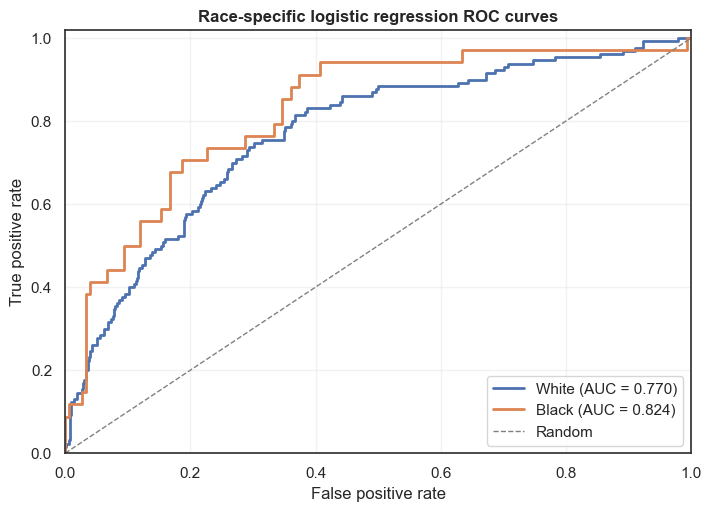

In [77]:
# Figure 22 — ROC curves by race
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for race, res in logit_results.items():
    fpr, tpr, _ = roc_curve(res['y'], res['y_prob'])
    ax.plot(fpr, tpr, linewidth=2, label=f'{race} (AUC = {res["auc"]:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1, label='Random')
ax.set_title('Race-specific logistic regression ROC curves')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc='lower right')
ax.grid(alpha=0.25)
fig.savefig(LOGIT_FIGURE_DIR / 'fig_22_logit_roc_by_race.png', dpi=200)
plt.show()


### ROC Curve Interpretation

Both race-specific ROC curves lie above the random-classification diagonal, indicating that the logistic models contain useful diabetes-risk information. The Black model has the higher AUC (0.824 vs. 0.770 for White respondents), so in this sample it more often assigns a higher predicted probability to diabetes-positive rows than to diabetes-negative rows.

This does not mean the Black model is definitively better in a population sense. The Black subset is much smaller, with only 34 diabetes-positive observations, so the ROC curve is more sensitive to sampling variation. The ROC results should be interpreted as evidence of moderate predictive ranking within each race subset, not as evidence that any risk factor causally affects diabetes.


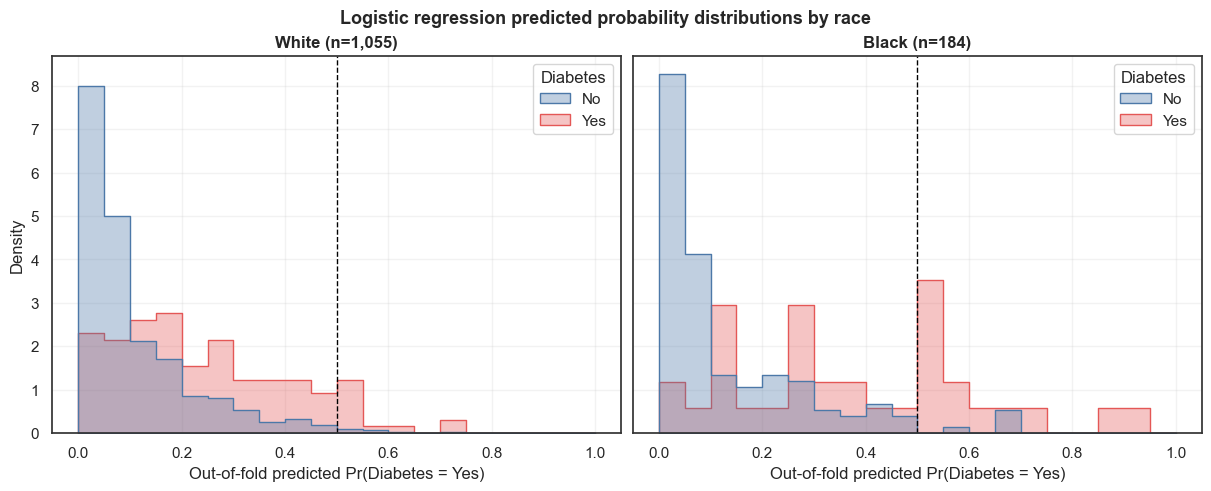

In [78]:
# Figure 23 — Out-of-fold predicted probabilities by true diabetes status
prob_records = []
for race, res in logit_results.items():
    for prob, y_val in zip(res['y_prob'], res['y']):
        prob_records.append({
            'race': race,
            'predicted_probability': float(prob),
            'Diabetes': 'Yes' if y_val == 1 else 'No',
        })
prob_plot = pd.DataFrame(prob_records)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True, sharex=True, sharey=True)
for ax, race in zip(axes, ['White', 'Black']):
    sns.histplot(
        data=prob_plot[prob_plot['race'] == race],
        x='predicted_probability', hue='Diabetes', hue_order=DIABETES_ORDER,
        bins=np.linspace(0, 1, 21), stat='density', common_norm=False,
        element='step', fill=True, alpha=0.35,
        palette=[OUTCOME_PALETTE['No'], OUTCOME_PALETTE['Yes']], ax=ax,
    )
    ax.axvline(LOGIT_THRESHOLD, color='black', linestyle='--', linewidth=1, label='0.5 threshold')
    ax.set_title(f'{race} (n={len(LOGIT_RACE_SUBSETS[race]):,})', fontweight='bold')
    ax.set_xlabel('Out-of-fold predicted Pr(Diabetes = Yes)')
    ax.set_ylabel('Density')
    ax.grid(alpha=0.25)
fig.suptitle('Logistic regression predicted probability distributions by race', fontsize=13, fontweight='bold')
fig.savefig(LOGIT_FIGURE_DIR / 'fig_23_logit_predicted_probabilities_by_race.png', dpi=200)
plt.show()


### Predicted Probability Interpretation

The predicted-probability distributions show substantial overlap between diabetes-positive and diabetes-negative respondents. This is expected for a compact observational risk-factor model: age, BMI, blood pressure status, cholesterol, poverty, gender, physical activity, and smoking provide useful risk information, but they do not cleanly separate diabetes status.

The White model assigns higher probabilities to diabetes-positive rows on average, but most values remain below the 0.5 threshold. About 90.8% of White diabetes-positive rows fall below 0.5, explaining the very low sensitivity in Table 18. The Black model shows stronger separation: the median predicted probability is 0.348 for diabetes-positive rows versus 0.062 for diabetes-negative rows, but 61.8% of Black diabetes-positive rows still fall below 0.5.

Overall, the model appears better at ranking relative risk than at classifying diabetes-positive cases using the default 0.5 cutoff. A lower threshold would increase sensitivity, but that would also increase false positives.


/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/george/Documents/GitHub/STAT-32950-Final-Project/.venv/lib/p

,race,feature,coefficient,odds_ratio,absolute_coefficient,absolute_coefficient_rank
9,Black,Age,1.3880,4.0068,1.3880,1
14,Black,Gender_male,0.7431,2.1025,0.7431,2
10,Black,BMI,0.7288,2.0726,0.7288,3
15,Black,HighBP_High,0.4792,1.6149,0.4792,4
11,Black,DirectChol,0.4133,1.5118,0.4133,5
12,Black,TotChol,-0.3075,0.7353,0.3075,6
13,Black,Poverty,-0.1795,0.8357,0.1795,7
16,Black,PhysActive_Yes,-0.1718,0.8421,0.1718,8
17,Black,SmokeNow_Yes,0.0595,1.0613,0.0595,9
0,White,Age,0.7590,2.1362,0.7590,1


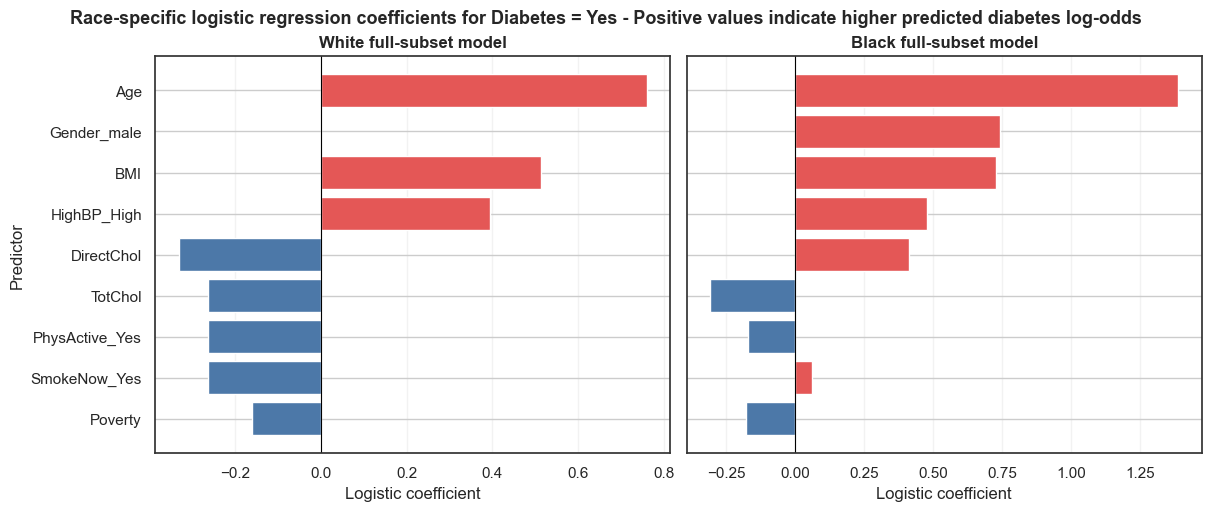

In [79]:
# Table 20 and Figure 24 — Final full-subset logistic coefficients
coef_records = []
for race, data in LOGIT_RACE_SUBSETS.items():
    X = data[LOGIT_FEATURES].copy()
    y = data[LOGIT_TARGET].eq('Yes').astype(int)
    final_model = make_logit_pipeline().fit(X, y)
    feature_names = final_model.named_steps['preprocess'].get_feature_names_out()
    coefs = final_model.named_steps['model'].coef_[0]
    for feature, coef in zip(feature_names, coefs):
        coef_records.append({
            'race': race,
            'feature': feature,
            'coefficient': round(float(coef), 4),
            'odds_ratio': round(float(np.exp(coef)), 4),
        })

logit_coefficients = pd.DataFrame(coef_records)
logit_coefficients['absolute_coefficient'] = logit_coefficients['coefficient'].abs()
logit_coefficients['absolute_coefficient_rank'] = (
    logit_coefficients
    .groupby('race')['absolute_coefficient']
    .rank(ascending=False, method='first')
    .astype(int)
)
logit_coefficients = logit_coefficients.sort_values(['race', 'absolute_coefficient_rank'])
logit_coefficients.to_csv(LOGIT_TABLE_DIR / 'table_20_logit_coefficients.csv', index=False)

display(logit_coefficients)

feature_order = (
    logit_coefficients.groupby('feature')['absolute_coefficient']
    .max().sort_values().index.tolist()
)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True, sharey=True)
for ax, race in zip(axes, ['White', 'Black']):
    sub = logit_coefficients[logit_coefficients['race'] == race].set_index('feature').reindex(feature_order)
    colors = ['#E45756' if v > 0 else '#4C78A8' for v in sub['coefficient']]
    ax.barh(sub.index, sub['coefficient'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{race} full-subset model', fontweight='bold')
    ax.set_xlabel('Logistic coefficient')
    ax.grid(axis='x', alpha=0.25)
axes[0].set_ylabel('Predictor')
fig.suptitle('Race-specific logistic regression coefficients for Diabetes = Yes - Positive values indicate higher predicted diabetes log-odds', fontsize=13, fontweight='bold')
fig.savefig(LOGIT_FIGURE_DIR / 'fig_24_logit_coefficients_by_race.png', dpi=200)
plt.show()


### Logistic Coefficient Interpretation

The coefficient patterns are broadly consistent with the earlier descriptive analysis. In both race-specific models, older age, higher BMI, and high blood pressure status are associated with higher predicted diabetes log-odds. These are the most stable shared risk signals across the White and Black subsets.

For White respondents, the largest positive coefficients are Age, BMI, and `HighBP_High`. Poverty, physical activity, smoking, and both cholesterol variables have negative coefficients in the fitted model, while gender is essentially zero. For Black respondents, Age is again the strongest positive predictor, followed by male gender, BMI, high blood pressure, and direct cholesterol. Poverty and physical activity have negative coefficients, while smoking is close to zero.

These coefficients should be read as model-based predictive associations, not causal effects. Numeric odds ratios correspond to a one-standard-deviation increase after scaling, and categorical odds ratios are relative to the omitted reference category. Because the Black model is fit on only 184 rows and 34 diabetes-positive cases, apparent race differences in coefficient size may reflect sampling variability, predictor correlation, and regularization rather than stable population-level differences.


## Generate Markdown Report

Writes `reports/01_descriptive_eda.md` — the same handoff note produced by the `.py` script.

In [80]:
overview_map = dict(zip(overview['metric'], overview['value']))
race_counts = df['Race1'].value_counts()
diabetes_yes_pct = pct(df['Diabetes'], 'Yes')
highbp_high_pct = pct(df['HighBP'], 'High')
black_diabetes = race_rates.loc[race_rates['race'] == 'Black', 'diabetes_yes_pct'].iloc[0]
white_diabetes = race_rates.loc[race_rates['race'] == 'White', 'diabetes_yes_pct'].iloc[0]
black_highbp  = race_rates.loc[race_rates['race'] == 'Black', 'highbp_high_pct'].iloc[0]
white_highbp  = race_rates.loc[race_rates['race'] == 'White', 'highbp_high_pct'].iloc[0]

report = f'''# Descriptive EDA: NHANES Adult Health Data

## Scope

This note covers project component 2 only: descriptive data exploration and visualization.
It does not run PCA, factor analysis, clustering, regression, classification,
hypothesis tests, or prediction models.

## Data

The source file is `data/nhanes_health.csv`. The project instructions describe this as a
simplified complete-case adult NHANES sample without survey weights, so all summaries below
describe this project sample rather than official U.S. population estimates.

Key dimensions:

- Rows: {int(overview_map["rows"]):,}
- Columns: {int(overview_map["columns"]):,}
- Missing cells: {int(overview_map["missing_cells"]):,}
- Exact duplicate rows across all selected variables: {int(overview_map["exact_duplicate_rows"]):,}
- Unique full profiles after exact-row collapse: {int(overview_map["unique_full_profiles"]):,}
- `BPDiaAve` values equal to 0: {int(overview_map["bpdiaave_zero_values"]):,}
- `HighBP` derivation mismatches: {int(overview_map["highbp_derivation_mismatches"]):,}

## Main Descriptive Findings

The sample is heavily White: {race_counts.get("White", 0):,} White rows and
{race_counts.get("Black", 0):,} Black rows out of {len(df):,}.

Overall, {diabetes_yes_pct:.1f}% of rows have `Diabetes = Yes` and
{highbp_high_pct:.1f}% have `HighBP = High`. By race, diabetes is
{black_diabetes:.1f}% for Black rows vs. {white_diabetes:.1f}% for White rows;
high BP is {black_highbp:.1f}% vs. {white_highbp:.1f}%.

## Selected Tables

Race-level descriptive rates:

{markdown_table(race_rates)}

White/Black profile:

{markdown_table(white_black_profile)}

## Handoff Notes

- Later modeling should decide whether to retain exact duplicate rows.
- The `BPDiaAve = 0` rows should be reviewed before blood-pressure modeling.
- Avoid language about national prevalence — survey weights are absent.
- The White/Black sample-size imbalance should be acknowledged in race-specific analyses.
'''

REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_PATH.write_text(report, encoding='utf-8')
print(f'Report written to {REPORT_PATH.relative_to(PROJECT_ROOT)}')

Report written to reports/01_descriptive_eda.md
